<a href="https://colab.research.google.com/github/spiky7000-collab/Feature_Matching_Benchmark/blob/main/Dataset_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ignore first code chunk

In [ ]:
from google.colab import drive
import os
import re
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path Configuration (Ensure 'Dataset' is a shortcut in your MyDrive)
BASE_PATH = '/content/drive/MyDrive/Dataset'

# Folder names as specified
folders = {
    'ref': os.path.join(BASE_PATH, 'Ref'),
    'true': os.path.join(BASE_PATH, 'True'),
    'ai': os.path.join(BASE_PATH, 'Edited')
}

def get_smart_map(path):
    """
    Creates a map { '001': 'any_prefix_001.any_extension' }
    Works with: img_001.png, ref_001.jpg, 001.jpeg, etc.
    """
    mapping = {}
    if not os.path.exists(path):
        print(f" Folder not found: {path}")
        return mapping

    # Supported image extensions
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')

    for f in os.listdir(path):
        # Clean file check
        if f.startswith('.') or not f.lower().endswith(valid_exts):
            continue

        # Extract the number from the filename using Regex
        # Matches the first sequence of digits found in the name
        match = re.search(r'(\d+)', f)
        if match:
            file_id = match.group(1)
            mapping[file_id] = f

    return mapping

# Build the maps for all three folders
ref_map = get_smart_map(folders['ref'])
true_map = get_smart_map(folders['true'])
ai_map = get_smart_map(folders['ai'])

# Use the IDs found in 'Ref' as the master list for the slider
all_ids = sorted(ref_map.keys())

print(f"✅ Sync Complete!")
print(f"Total Reference IDs found: {len(all_ids)}")
print(f"Matching 'True' files: {len(true_map)}")
print(f"Matching 'Edited' files: {len(ai_map)}")

if len(all_ids) > 0:
    print(f"Example match for ID {all_ids[0]}:")
    print(f"  - Ref: {ref_map.get(all_ids[0])}")
    print(f"  - True: {true_map.get(all_ids[0])}")
    print(f"  - Edited: {ai_map.get(all_ids[0])}")

Mounted at /content/drive
✅ Sync Complete!
Total Reference IDs found: 200
Matching 'True' files: 200
Matching 'Edited' files: 200
Example match for ID 001:
  - Ref: img_001.png
  - True: true_001.png
  - Edited: edited_001.png


In [ ]:
from IPython.display import HTML, display

# Élargit la zone d'affichage de Google Colab
display(HTML("""
<style>
  .output_area { max-width: 100% !important; }
  .output_subarea { max-width: 100% !important; overflow-x: hidden !important; }
  div.jp-OutputArea-output { max-width: 100% !important; }
</style>
"""))

Setting up slider (To see images)

In [ ]:
def universal_explorer(index):
    if not all_ids:
        print("No images found. Check your folder names and Drive connection.")
        return

    img_id = all_ids[index]

    fig, axes = plt.subplots(1, 3, figsize=(22, 8))

    # Content to display
    display_data = [
        (folders['ref'], ref_map.get(img_id), "Reference (Ref)"),
        (folders['true'], true_map.get(img_id), "Actual Angle (True)"),
        (folders['ai'], ai_map.get(img_id), "AI Transformation (Edited)")
    ]

    for i, (folder_path, filename, title) in enumerate(display_data):
        if filename:
            full_path = os.path.join(folder_path, filename)
            try:
                img = Image.open(full_path)
                axes[i].imshow(img)
                # Show the title + the actual filename found
                axes[i].set_title(f"{title}\n{filename}", fontsize=11, fontweight='bold')
            except Exception as e:
                axes[i].text(0.5, 0.5, f"Corrupted File\n{filename}", ha='center', color='orange')
        else:
            # Visual feedback if a file is missing in one of the folders
            axes[i].text(0.5, 0.5, f"MISSING\nID: {img_id}",
                         ha='center', va='center', color='red', fontsize=14, fontweight='bold')
            axes[i].set_facecolor('#fff5f5')

        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(universal_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Image ID:',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))

interactive(children=(IntSlider(value=0, description='Image ID:', layout=Layout(width='600px'), max=199, style…

Experience 1: Ref,True (feature Matching + RANSAC)

a. SIFT (Brute Force then FLANN)

In [ ]:
##IGNORE
# SIFT method (BruteForce and SLANN)

import cv2
import numpy as np

# Initialiser le détecteur SIFT
sift = cv2.SIFT_create()

# Créer l'objet "Matcher" pour lier les points entre les images
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

In [ ]:
#BRUTEFORCE ALL POINTS
def draw_sift_clean(ax, img1_path, img2_path, title, color_title):
    """Dessine tous les points SIFT avec un code couleur : Vert (Top), Orange (Moyen), Rouge (Pire)."""
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0

    # 1. Lecture des images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0

    # 2. Conversion et SIFT
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # ---> AJOUT ICI : Calcul du nombre de keypoints
    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    # Sécurité au cas où l'image n'a aucun point clé
    if des1 is None or des2 is None:
        ax.text(0.5, 0.5, "Pas assez de points trouvés", ha='center', va='center', color='red')
        ax.axis('off')
        return 0

    # 3. Matching et Tri (du meilleur au pire)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    total_matches = len(matches)

    if total_matches == 0:
        ax.axis('off')
        return 0

    # 4. Découpage en 3 tiers (Top 33%, Milieu 33%, Bas 33%)
    tier1 = total_matches // 3
    tier2 = 2 * (total_matches // 3)

    good_matches = matches[:tier1]         # Les meilleurs
    medium_matches = matches[tier1:tier2]  # Les moyens
    bad_matches = matches[tier2:]          # Les pires

    # 5. Dessin par couches successives (OpenCV utilise le format BGR)

    # Couche 1 : Rouge (Pires matchs) au fond
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, bad_matches, None,
                                 matchColor=(0, 0, 255), # Rouge BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Couche 2 : Orange (Matchs moyens) par dessus
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, medium_matches, img_result,
                                 matchColor=(0, 165, 255), # Orange BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Couche 3 : Vert (Bons matchs) tout au dessus
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, img_result,
                                 matchColor=(0, 255, 0), # Vert BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # 6. Affichage Matplotlib
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)

    titre_complet = (f"{title}\n"
                     f"Matchs: {total_matches} (Vert: {len(good_matches)} | Orange: {len(medium_matches)} | Rouge: {len(bad_matches)})\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return total_matches

def sift_explorer_v2(index):
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    # path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # On crée 1 ligne
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))

    # Ligne 1 : Ref <-> True
    draw_sift_clean(ax1, path_r, path_t, "MATCHING: Ref ↔ True", "blue")

    # Ligne 2 : Ref <-> Edited
    # draw_sift_clean(ax2, path_r, path_e, "MATCHING: Ref ↔ Edited", "green")

    plt.tight_layout()
    plt.show()

# Relancer le widget
widgets.interact(sift_explorer_v2, index=widgets.IntSlider(min=0, max=len(all_ids)-1, value=0, description='Analyser ID:'))

interactive(children=(IntSlider(value=0, description='Analyser ID:', max=199), Output()), _dom_classes=('widge…

<function __main__.sift_explorer_v2(index)>

In [ ]:
#FLANN
def draw_sift_flann(ax, img1_path, img2_path, title, color_title):
    """Dessine tous les points SIFT avec le moteur FLANN et un code couleur (Vert/Orange/Rouge)."""
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0

    # 1. Lecture des images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0

    # 2. Conversion et SIFT
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    # Sécurité FLANN : s'assurer qu'il y a assez de points pour comparer
    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés", ha='center', va='center', color='red')
        ax.axis('off')
        return 0

    # 3.CONFIGURATION FLANN
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 50) # Plus le chiffre est haut, plus c'est précis mais lent

    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # 4. Matching et Tri (du meilleur au pire)
    matches = flann.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    total_matches = len(matches)

    if total_matches == 0:
        ax.axis('off')
        return 0

    # 5. Découpage en 3 tiers (Top 33%, Milieu 33%, Bas 33%)
    tier1 = total_matches // 3
    tier2 = 2 * (total_matches // 3)

    good_matches = matches[:tier1]         # Les meilleurs
    medium_matches = matches[tier1:tier2]  # Les moyens
    bad_matches = matches[tier2:]          # Les pires

    # 6. Dessin par couches successives (Rouge au fond, Vert devant)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, bad_matches, None,
                                 matchColor=(0, 0, 255), # Rouge BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_result = cv2.drawMatches(img1, kp1, img2, kp2, medium_matches, img_result,
                                 matchColor=(0, 165, 255), # Orange BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, img_result,
                                 matchColor=(0, 255, 0), # Vert BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # 7. Affichage Matplotlib
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"Total FLANN: {total_matches} (Vert: {len(good_matches)} | Orange: {len(medium_matches)} | Rouge: {len(bad_matches)})\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return total_matches

def sift_explorer_flann(index):
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    # path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # On crée 1 ligne
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))

    # Appel de la nouvelle fonction FLANN
    draw_sift_flann(ax1, path_r, path_t, "MATCHING: Ref ↔ True", "blue")
    # draw_sift_flann(ax2, path_r, path_e, "MATCHING: Ref ↔ Edited", "green")

    plt.tight_layout()
    plt.show()

# Lancement du widget
if all_ids:
    widgets.interact(sift_explorer_flann, index=widgets.IntSlider(min=0, max=len(all_ids)-1, value=0, description='Analyser ID:'))

interactive(children=(IntSlider(value=0, description='Analyser ID:', max=199), Output()), _dom_classes=('widge…

b. ROMAV2

In [ ]:
import torch
import gc

In [ ]:
#to install vismatch
!pip install uv
#YAHIA a rajouté un commentaire pour ne pas créer de venv
#!uv venv --python 3.13
!uv pip install vismatch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 83.8 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 124 packages in 1.75s
Prepared 24 packages in 3.17s
Uninstalled 1 package in 1ms
Installed 24 packages in 114ms
 + e2cnn==0.2.3
 + flow-vis==0.1
 + jaxtyping==0.3.9
 + kornia==0.8.2
 + kornia-moons==0.2.9
 + kornia-rs==0.1.11
 + lightning==2.3.3
 + lightning-utilities==0.15.3
 + loguru==0.7.3
 + minio==7.2.20
 - packaging==26.1
 + packaging==24.2
 + poselib==2.0.5
 + py3-wget==1.0.13
 + pycryptodome==3.23.0
 + pytorch-lightning==2.6.1
 + rerun-sdk==0.31.4
 + roma==1.5.6
 + torchmetrics==1.9.0
 + transforms3d==0.4.2
 + trimesh==4.12.2
 + uniception==0.1.1
 + vismatch==1.2.1
 + wadler-lindig==0.1.7
 + yacs==0.1.8


In [ ]:
from vismatch import get_matcher
from vismatch.viz import plot_matches
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os

# Choose any of the 50+ available matchers, like superpoint-lightglue
matcher = get_matcher("romav2", device="cuda")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Downloading: "https://github.com/facebookresearch/dinov3/zipball/adc254450203739c8149213a7a69d8d905b4fcfa" to /root/.cache/torch/hub/adc254450203739c8149213a7a69d8d905b4fcfa.zip
Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:03<00:00, 175MB/s]


2026-05-12 13:36:25 INFO     romav2.romav2 - romav2:118 in __init__ - RoMa v2 initialized.

Downloading: "https://github.com/Parskatt/RoMaV2/releases/download/weights/romav2.pt" to /root/.cache/torch/hub/checkpoints/romav2.pt


100%|██████████| 1.02G/1.02G [00:14<00:00, 74.3MB/s]


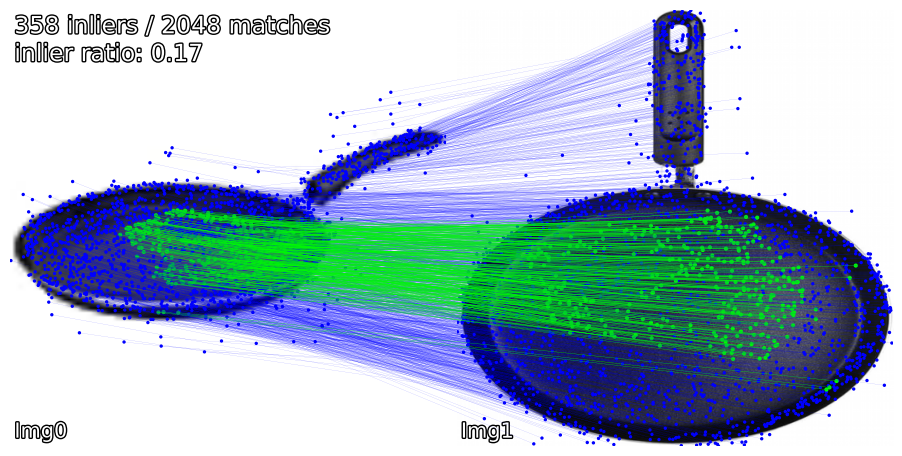

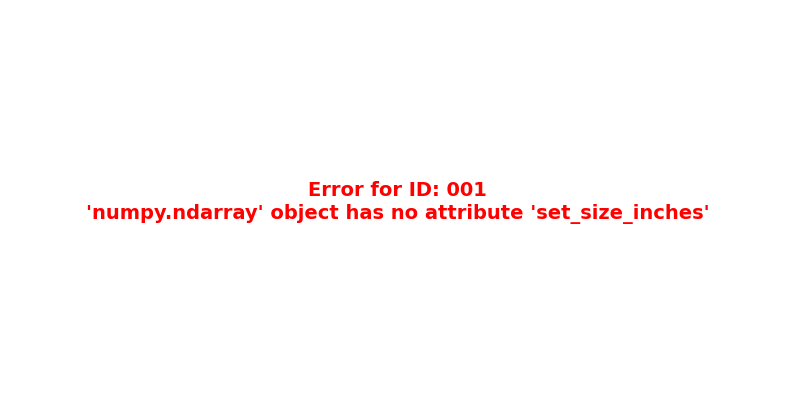

In [ ]:
def romav2_explorer(index):
    if not all_ids:
        print("No images found. Check your folder names and Drive connection.")
        return

    img_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(img_id)) if ref_map.get(img_id) else None
    path_t = os.path.join(folders['true'], true_map.get(img_id)) if true_map.get(img_id) else None

    if not path_r or not path_t:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.text(0.5, 0.5, f"MISSING files for ID: {img_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.show()
        return

    try:
        ref_img = matcher.load_image(path_r, resize=512)
        true_img = matcher.load_image(path_t, resize=512)

        result = matcher(ref_img, true_img)
        # plot_matches returns a matplotlib figure. We can display it directly.
        fig_matches = plot_matches(ref_img, true_img, result)
        fig_matches.set_size_inches(18, 7)
        fig_matches.suptitle(f"ROMAV2 Matching: Ref \u2194 True (ID: {img_id})")
        plt.show()
    except Exception as e:
        print(f"Error processing ID {img_id}: {e}")
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.text(0.5, 0.5, f"Error for ID: {img_id}\n{e}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(romav2_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Image ID:',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))
else:
    print("No image IDs found to create the slider.")

c. RANSAC SCORE on each method

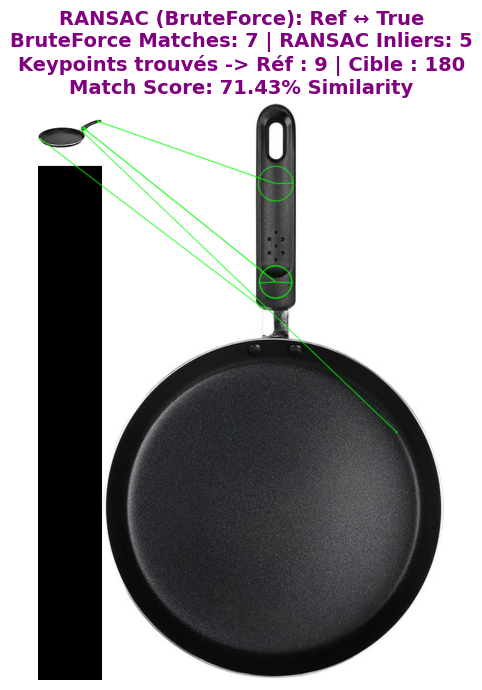

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os

# SIFT detector and BFMatcher are already initialized in cell lH4B8Kt6kJJA
# sift = cv2.SIFT_create()
# bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

def draw_sift_bruteforce_ransac(ax, img1_path, img2_path, title, color_title):
    """Dessine les points SIFT appariés avec BruteForce et filtrés par RANSAC.
    Retourne le pourcentage d'inliers RANSAC.
    """
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0.0

    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0.0

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés pour RANSAC", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0

    # Perform Brute-Force matching (with crossCheck=True for initial good matches)
    initial_matches = bf.match(des1, des2)

    if len(initial_matches) < 4: # RANSAC requires at least 4 points
        ax.text(0.5, 0.5, f"Pas assez de bons matchs ({len(initial_matches)}) pour RANSAC", ha='center', va='center', color='orange')
        ax.axis('off')
        return 0.0

    # Extract keypoints for RANSAC from initial_matches
    src_pts = np.float32([kp1[m.queryIdx].pt for m in initial_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in initial_matches]).reshape(-1, 1, 2)

    # Find Homography and RANSAC mask
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist()

    # Filter initial_matches using the RANSAC mask to get inliers
    inlier_matches = [m for i, m in enumerate(initial_matches) if matches_mask[i]]

    if len(inlier_matches) == 0:
        ax.text(0.5, 0.5, "Aucun inlier RANSAC trouvé", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0

    # Calculate percentage
    match_percentage = (len(inlier_matches) / len(initial_matches)) * 100 if len(initial_matches) > 0 else 0.0

    # Draw only inlier matches (green color)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, inlier_matches, None,
                                 matchColor=(0, 255, 0), # Green BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS | cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"BruteForce Matches: {len(initial_matches)} | RANSAC Inliers: {len(inlier_matches)}\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return match_percentage

def sift_bruteforce_ransac_explorer(index):
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None

    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))

    match_percentage = draw_sift_bruteforce_ransac(ax1, path_r, path_t, "RANSAC (BruteForce): Ref \u2194 True", "blue")

    if match_percentage > 0:
        current_title = ax1.get_title()
        ax1.set_title(f"{current_title}\nMatch Score: {match_percentage:.2f}% Similarity", fontsize=14, color="purple", fontweight='bold')
    elif match_percentage == 0:
        current_title = ax1.get_title()
        if "Aucun inlier RANSAC trouvé" not in current_title and "Pas assez de bons matchs" not in current_title:
             ax1.set_title(f"{current_title}\nMatch Score: 0.00% Similarity", fontsize=14, color="purple", fontweight='bold')

    plt.tight_layout()
    plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(sift_bruteforce_ransac_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Analyser ID (BruteForce+RANSAC):',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))
else:
    print("No image IDs found to create the slider.")

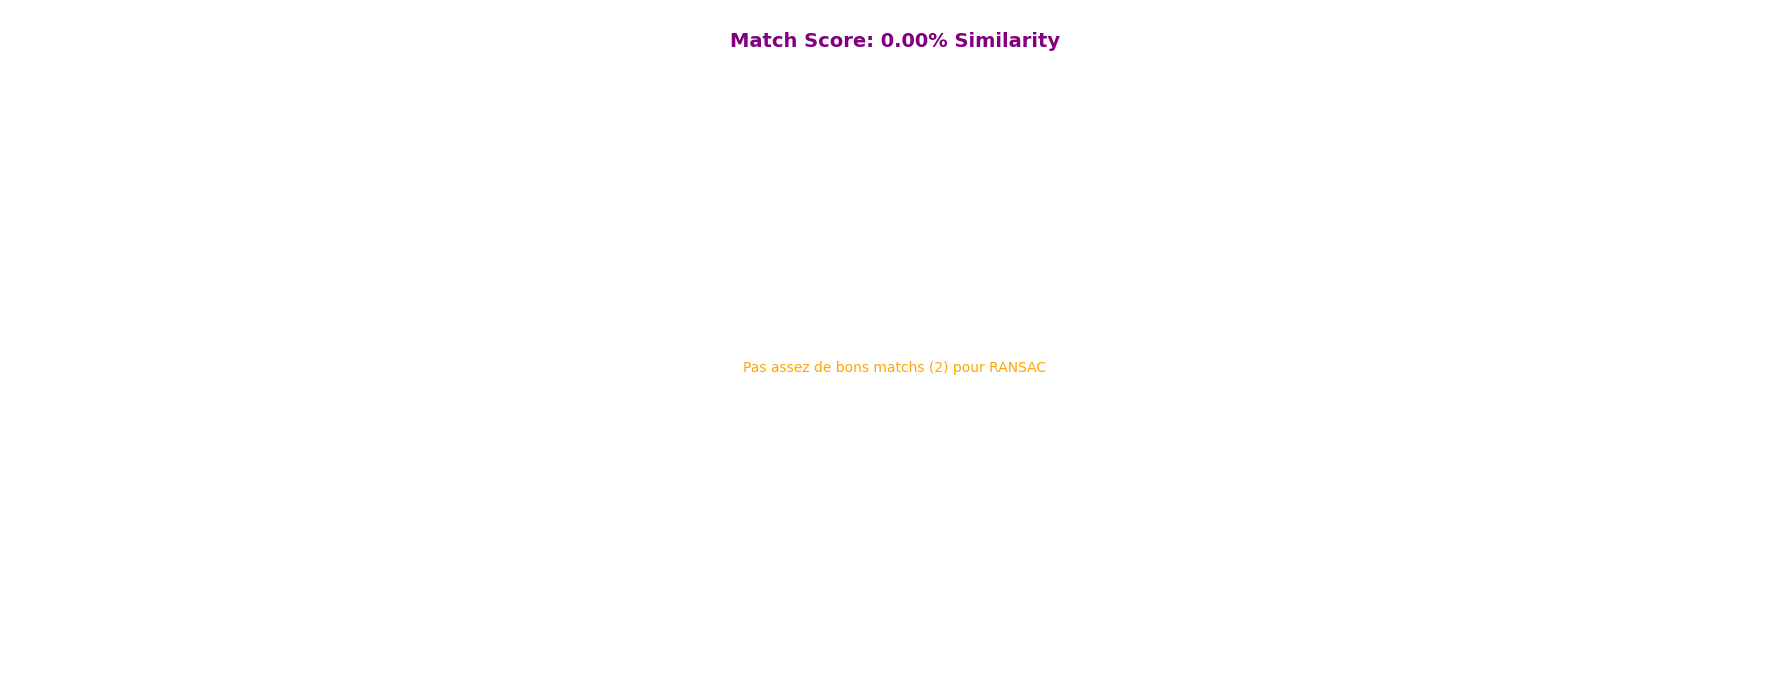

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os

# SIFT detector is already initialized in cell lH4B8Kt6kJJA
# sift = cv2.SIFT_create()

def draw_sift_flann_ransac(ax, img1_path, img2_path, title, color_title):
    """Dessine les points SIFT appariés avec FLANN et filtrés par RANSAC.
    Retourne le pourcentage d'inliers RANSAC.
    """
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0.0

    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0.0

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés pour RANSAC", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0

    # FLANN parameters
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des1, des2, k=2)

    # Apply ratio test (Lowe's ratio test)
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    if len(good_matches) < 4: # RANSAC requires at least 4 points
        ax.text(0.5, 0.5, f"Pas assez de bons matchs ({len(good_matches)}) pour RANSAC", ha='center', va='center', color='orange')
        ax.axis('off')
        return 0.0

    # Extract keypoints for RANSAC
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Find Homography and RANSAC mask
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist()

    # Filter good matches using the RANSAC mask
    inlier_matches = [m for i, m in enumerate(good_matches) if matches_mask[i]]

    if len(inlier_matches) == 0:
        ax.text(0.5, 0.5, "Aucun inlier RANSAC trouvé", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0

    # Calculate percentage
    match_percentage = (len(inlier_matches) / len(good_matches)) * 100 if len(good_matches) > 0 else 0.0

    # Draw only inlier matches (green color)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, inlier_matches, None,
                                 matchColor=(0, 255, 0), # Green BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS | cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"FLANN Good Matches: {len(good_matches)} | RANSAC Inliers: {len(inlier_matches)}\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return match_percentage

def ransac_explorer(index):
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None

    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))

    match_percentage = draw_sift_flann_ransac(ax1, path_r, path_t, "RANSAC: Ref \u2194 True", "blue")

    if match_percentage > 0:
        current_title = ax1.get_title()
        ax1.set_title(f"{current_title}\nMatch Score: {match_percentage:.2f}% Similarity", fontsize=14, color="purple", fontweight='bold')
    elif match_percentage == 0:
        current_title = ax1.get_title()
        if "Aucun inlier RANSAC trouvé" not in current_title and "Pas assez de bons matchs" not in current_title:
             ax1.set_title(f"{current_title}\nMatch Score: 0.00% Similarity", fontsize=14, color="purple", fontweight='bold')

    plt.tight_layout()
    plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(ransac_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Image ID:',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))
else:
    print("No image IDs found to create the slider.")

YAHIA APPLIQUE RANSAC SUR LES PAIRES REF, TRUE AVEC LA METHODE ROMAV2

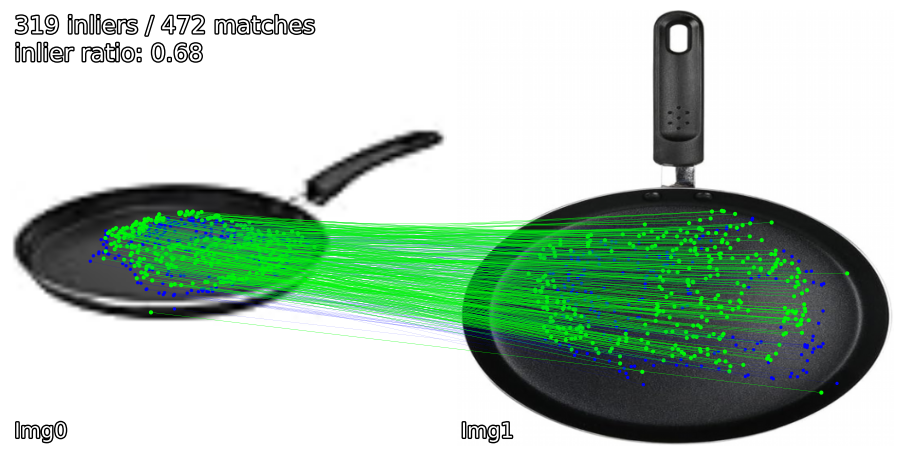

In [ ]:
def draw_romav2_ransac(img_A, img_B, ransac_threshold=5.0):
    """Applique RoMA-v2, filtre avec RANSAC et retourne les points valides et le score."""
    with torch.no_grad():
        result = matcher(img_A, img_B)

    pts_A = np.array(result["matched_kpts0"])
    pts_B = np.array(result["matched_kpts1"])
    total_kp = len(pts_A)

    if total_kp < 4:
        return result, 0.0, total_kp, 0

    # Calcul RANSAC
    M, mask = cv2.findHomography(pts_A, pts_B, cv2.RANSAC, ransac_threshold)

    if mask is not None:
        inliers_mask = mask.ravel().astype(bool)
        nb_inliers = np.sum(inliers_mask)
        score_ransac = (nb_inliers / total_kp) * 100

        # Filtrer le dictionnaire de résultats pour ne garder que les inliers
        result["matched_kpts0"] = pts_A[inliers_mask]
        result["matched_kpts1"] = pts_B[inliers_mask]
        if "mconf" in result:
            result["mconf"] = np.array(result["mconf"])[inliers_mask]
    else:
        nb_inliers = 0
        score_ransac = 0.0

    return result, score_ransac, total_kp, nb_inliers

def romav2_ransac_explorer_ref_true(index):
    if not all_ids: return
    img_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(img_id)) if ref_map.get(img_id) else None
    path_t = os.path.join(folders['true'], true_map.get(img_id)) if true_map.get(img_id) else None

    if not path_r or not path_t:
        print(f"Fichier manquant pour l'ID {img_id}")
        return

    try:
        img_source = matcher.load_image(path_r, resize=512)
        img_target = matcher.load_image(path_t, resize=512)

        result_filtre, score, total_kp, inliers = draw_romav2_ransac(img_source, img_target)

        fig_matches = plot_matches(img_source, img_target, result_filtre)
        fig_matches.set_size_inches(18, 7)

        titre = f"ROMA-v2 + RANSAC : Ref ↔ True (ID: {img_id})\nMATCH SCORE: {score:.2f}% (Inliers: {inliers}/{total_kp})"
        fig_matches.suptitle(titre, fontsize=16, fontweight='bold', color='purple')
        plt.show()

        del img_source, img_target, result_filtre, fig_matches
        gc.collect()
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"Erreur : {e}")

if all_ids:
    widgets.interact(romav2_ransac_explorer_ref_true, index=widgets.IntSlider(min=0, max=len(all_ids)-1, step=1, value=0, description='Analyser ID:'))

Experience 2: Ref,Edit (feature Matching + RANSAC)

a. SIFT (Brute Force then FLANN)

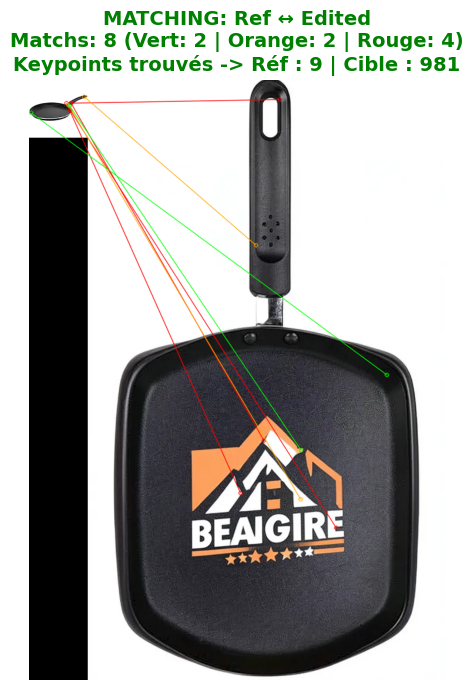

<function __main__.sift_explorer_v2(index)>

In [ ]:
def draw_sift_clean(ax, img1_path, img2_path, title, color_title):
    """Dessine tous les points SIFT avec un code couleur : Vert (Top), Orange (Moyen), Rouge (Pire)."""
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0

    # 1. Lecture des images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0

    # 2. Conversion et SIFT
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # ---> AJOUT ICI : Calcul du nombre de keypoints
    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    # Sécurité au cas où l'image n'a aucun point clé
    if des1 is None or des2 is None:
        ax.text(0.5, 0.5, "Pas assez de points trouvés", ha='center', va='center', color='red')
        ax.axis('off')
        return 0

    # 3. Matching et Tri (du meilleur au pire)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    total_matches = len(matches)

    if total_matches == 0:
        ax.axis('off')
        return 0

    # 4. Découpage en 3 tiers (Top 33%, Milieu 33%, Bas 33%)
    tier1 = total_matches // 3
    tier2 = 2 * (total_matches // 3)

    good_matches = matches[:tier1]         # Les meilleurs
    medium_matches = matches[tier1:tier2]  # Les moyens
    bad_matches = matches[tier2:]          # Les pires

    # 5. Dessin par couches successives (OpenCV utilise le format BGR)

    # Couche 1 : Rouge (Pires matchs) au fond
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, bad_matches, None,
                                 matchColor=(0, 0, 255), # Rouge BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Couche 2 : Orange (Matchs moyens) par dessus
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, medium_matches, img_result,
                                 matchColor=(0, 165, 255), # Orange BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Couche 3 : Vert (Bons matchs) tout au dessus
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, img_result,
                                 matchColor=(0, 255, 0), # Vert BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # 6. Affichage Matplotlib
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)

    titre_complet = (f"{title}\n"
                     f"Matchs: {total_matches} (Vert: {len(good_matches)} | Orange: {len(medium_matches)} | Rouge: {len(bad_matches)})\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return total_matches

def sift_explorer_v2(index):
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    # path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # On crée 1 ligne
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7)) # Changed to 1, 1 subplot

    # Ligne 1 : Ref <-> Edited
    draw_sift_clean(ax1, path_r, path_e, "MATCHING: Ref \u2194 Edited", "green") # Used ax1 for the desired plot

    plt.tight_layout()
    plt.show()

# Relancer le widget
widgets.interact(sift_explorer_v2, index=widgets.IntSlider(min=0, max=len(all_ids)-1, value=0, description='Analyser ID:'))

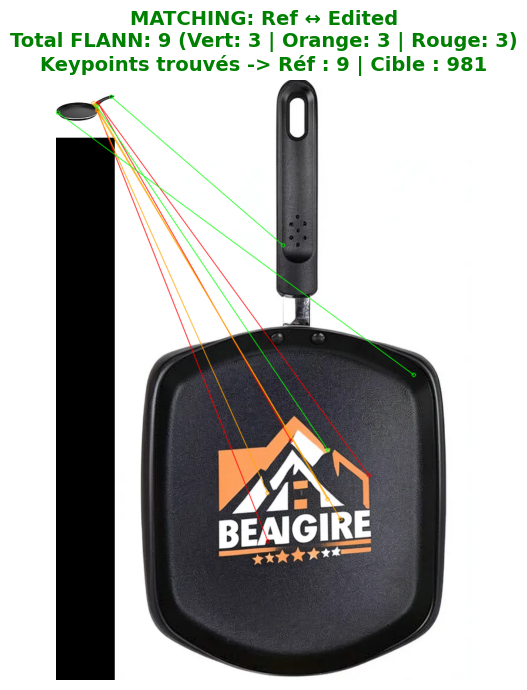

In [ ]:
def draw_sift_flann(ax, img1_path, img2_path, title, color_title):
    """Dessine tous les points SIFT avec le moteur FLANN et un code couleur (Vert/Orange/Rouge)."""
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0

    # 1. Lecture des images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0

    # 2. Conversion et SIFT
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    # Sécurité FLANN : s'assurer qu'il y a assez de points pour comparer
    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés", ha='center', va='center', color='red')
        ax.axis('off')
        return 0

    # 3.CONFIGURATION FLANN
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 50) # Plus le chiffre est haut, plus c'est précis mais lent

    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # 4. Matching et Tri (du meilleur au pire)
    matches = flann.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    total_matches = len(matches)

    if total_matches == 0:
        ax.axis('off')
        return 0

    # 5. Découpage en 3 tiers (Top 33%, Milieu 33%, Bas 33%)
    tier1 = total_matches // 3
    tier2 = 2 * (total_matches // 3)

    good_matches = matches[:tier1]         # Les meilleurs
    medium_matches = matches[tier1:tier2]  # Les moyens
    bad_matches = matches[tier2:]          # Les pires

    # 6. Dessin par couches successives (Rouge au fond, Vert devant)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, bad_matches, None,
                                 matchColor=(0, 0, 255), # Rouge BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_result = cv2.drawMatches(img1, kp1, img2, kp2, medium_matches, img_result,
                                 matchColor=(0, 165, 255), # Orange BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, img_result,
                                 matchColor=(0, 255, 0), # Vert BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # 7. Affichage Matplotlib
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"Total FLANN: {total_matches} (Vert: {len(good_matches)} | Orange: {len(medium_matches)} | Rouge: {len(bad_matches)})\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return total_matches

def sift_explorer_flann(index):
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    # path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # On crée 1 ligne
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))

    # Appel de la nouvelle fonction FLANN, only for Ref <-> Edited
    draw_sift_flann(ax1, path_r, path_e, "MATCHING: Ref \u2194 Edited", "green")

    plt.tight_layout()
    plt.show()

# Lancement du widget
if all_ids:
    widgets.interact(sift_explorer_flann, index=widgets.IntSlider(min=0, max=len(all_ids)-1, value=0, description='Analyser ID:'))

b. ROMAV2

Error processing ID 001: 'numpy.ndarray' object has no attribute 'set_size_inches'


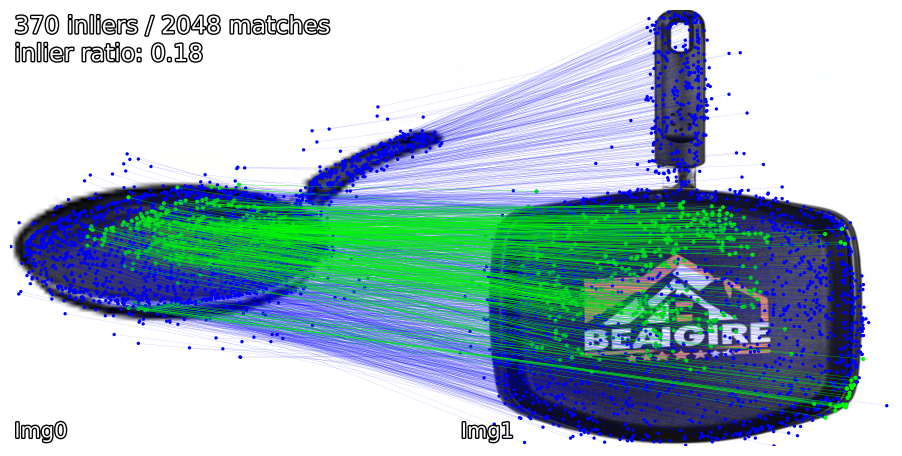

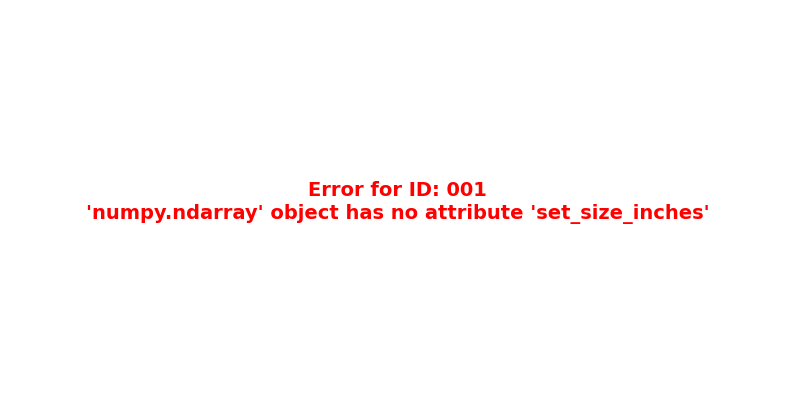

In [ ]:
# Choose any of the 50+ available matchers, like superpoint-lightglue
matcher = get_matcher("romav2", device="cuda")

def romav2_explorer(index):
    if not all_ids:
        print("No images found. Check your folder names and Drive connection.")
        return

    img_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(img_id)) if ref_map.get(img_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(img_id)) if ai_map.get(img_id) else None

    if not path_r or not path_e:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.text(0.5, 0.5, f"MISSING files for ID: {img_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.show()
        return

    try:
        ref_img = matcher.load_image(path_r, resize=512)
        edited_img = matcher.load_image(path_e, resize=512)

        result = matcher(ref_img, edited_img)
        # plot_matches returns a matplotlib figure. We can display it directly.
        fig_matches = plot_matches(ref_img, edited_img, result)
        fig_matches.set_size_inches(18, 7)
        fig_matches.suptitle(f"ROMAV2 Matching: Ref \u2194 Edited (ID: {img_id})")
        plt.show()
    except Exception as e:
        print(f"Error processing ID {img_id}: {e}")
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.text(0.5, 0.5, f"Error for ID: {img_id}\n{e}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(romav2_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Image ID:',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))
else:
    print("No image IDs found to create the slider.")

c. RANSAC (BruteForce then FLANN)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os

# SIFT detector and BFMatcher are already initialized in cell lH4B8Kt6kJJA
# sift = cv2.SIFT_create()
# bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

def draw_sift_bruteforce_ransac(ax, img1_path, img2_path, title, color_title):
    """Dessine les points SIFT appariés avec BruteForce et filtrés par RANSAC.
    Retourne le pourcentage d'inliers RANSAC.
    """
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0.0

    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0.0

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés pour RANSAC", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0

    # Perform Brute-Force matching (with crossCheck=True for initial good matches)
    initial_matches = bf.match(des1, des2)

    if len(initial_matches) < 4: # RANSAC requires at least 4 points
        ax.text(0.5, 0.5, f"Pas assez de bons matchs ({len(initial_matches)}) pour RANSAC", ha='center', va='center', color='orange')
        ax.axis('off')
        return 0.0

    # Extract keypoints for RANSAC from initial_matches
    src_pts = np.float32([kp1[m.queryIdx].pt for m in initial_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in initial_matches]).reshape(-1, 1, 2)

    # Find Homography and RANSAC mask
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist()

    # Filter initial_matches using the RANSAC mask to get inliers
    inlier_matches = [m for i, m in enumerate(initial_matches) if matches_mask[i]]

    if len(inlier_matches) == 0:
        ax.text(0.5, 0.5, "Aucun inlier RANSAC trouvé", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0

    # Calculate percentage
    match_percentage = (len(inlier_matches) / len(initial_matches)) * 100 if len(initial_matches) > 0 else 0.0

    # Draw only inlier matches (green color)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, inlier_matches, None,
                                 matchColor=(0, 255, 0), # Green BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS | cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"BruteForce Matches: {len(initial_matches)} | RANSAC Inliers: {len(inlier_matches)}\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return match_percentage

def sift_bruteforce_ransac_explorer(index):
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None # Changed from path_t

    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))

    match_percentage = draw_sift_bruteforce_ransac(ax1, path_r, path_e, "RANSAC (BruteForce): Ref \u2194 Edited", "green") # Changed title and color_title

    if match_percentage > 0:
        current_title = ax1.get_title()
        ax1.set_title(f"{current_title}\nMatch Score: {match_percentage:.2f}% Similarity", fontsize=14, color="purple", fontweight='bold')
    elif match_percentage == 0:
        current_title = ax1.get_title()
        if "Aucun inlier RANSAC trouvé" not in current_title and "Pas assez de bons matchs" not in current_title:
             ax1.set_title(f"{current_title}\nMatch Score: 0.00% Similarity", fontsize=14, color="purple", fontweight='bold')

    plt.tight_layout()
    plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(sift_bruteforce_ransac_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Analyser ID (BruteForce+RANSAC):',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))
else:
    print("No image IDs found to create the slider.")

interactive(children=(IntSlider(value=0, description='Analyser ID (BruteForce+RANSAC):', layout=Layout(width='…

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os

# SIFT detector is already initialized in cell lH4B8Kt6kJJA
# sift = cv2.SIFT_create()

def draw_sift_flann_ransac(ax, img1_path, img2_path, title, color_title):
    """Dessine les points SIFT appariés avec FLANN et filtrés par RANSAC.
    Retourne le pourcentage d'inliers RANSAC.
    """
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0.0

    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0.0

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés pour RANSAC", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0

    # FLANN parameters
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des1, des2, k=2)

    # Apply ratio test (Lowe's ratio test)
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    if len(good_matches) < 4: # RANSAC requires at least 4 points
        ax.text(0.5, 0.5, f"Pas assez de bons matchs ({len(good_matches)}) pour RANSAC", ha='center', va='center', color='orange')
        ax.axis('off')
        return 0.0

    # Extract keypoints for RANSAC
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Find Homography and RANSAC mask
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist()

    # Filter good matches using the RANSAC mask
    inlier_matches = [m for i, m in enumerate(good_matches) if matches_mask[i]]

    if len(inlier_matches) == 0:
        ax.text(0.5, 0.5, "Aucun inlier RANSAC trouvé", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0

    # Calculate percentage
    match_percentage = (len(inlier_matches) / len(good_matches)) * 100 if len(good_matches) > 0 else 0.0

    # Draw only inlier matches (green color)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, inlier_matches, None,
                                 matchColor=(0, 255, 0), # Green BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS | cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"FLANN Good Matches: {len(good_matches)} | RANSAC Inliers: {len(inlier_matches)}\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return match_percentage

def ransac_explorer(index):
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))

    match_percentage = draw_sift_flann_ransac(ax1, path_r, path_e, "RANSAC: Ref \u2194 Edited", "green")

    if match_percentage > 0:
        current_title = ax1.get_title()
        ax1.set_title(f"{current_title}\nMatch Score: {match_percentage:.2f}% Similarity", fontsize=14, color="purple", fontweight='bold')
    elif match_percentage == 0:
        current_title = ax1.get_title()
        if "Aucun inlier RANSAC trouvé" not in current_title and "Pas assez de bons matchs" not in current_title:
             ax1.set_title(f"{current_title}\nMatch Score: 0.00% Similarity", fontsize=14, color="purple", fontweight='bold')

    plt.tight_layout()
    plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(ransac_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Image ID:',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))
else:
    print("No image IDs found to create the slider.")

interactive(children=(IntSlider(value=0, description='Image ID:', layout=Layout(width='600px'), max=199, style…

YAHIA APPLIQUE RANSAC SUR LES PAIRES REF, EDIT AVEC LA METHODE ROMAV2

In [ ]:
def romav2_ransac_explorer_ref_edit(index):
    if not all_ids: return
    img_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(img_id)) if ref_map.get(img_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(img_id)) if ai_map.get(img_id) else None

    if not path_r or not path_e:
        print(f"Fichier manquant pour l'ID {img_id}")
        return

    try:
        img_source = matcher.load_image(path_r, resize=512)
        img_target = matcher.load_image(path_e, resize=512)

        result_filtre, score, total_kp, inliers = draw_romav2_ransac(img_source, img_target)

        fig_matches = plot_matches(img_source, img_target, result_filtre)
        fig_matches.set_size_inches(18, 7)

        titre = f"ROMA-v2 + RANSAC : Ref ↔ Edited (ID: {img_id})\nMATCH SCORE: {score:.2f}% (Inliers: {inliers}/{total_kp})"
        fig_matches.suptitle(titre, fontsize=16, fontweight='bold', color='purple')
        plt.show()

        del img_source, img_target, result_filtre, fig_matches
        gc.collect()
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"Erreur : {e}")

if all_ids:
    widgets.interact(romav2_ransac_explorer_ref_edit, index=widgets.IntSlider(min=0, max=len(all_ids)-1, step=1, value=0, description='Analyser ID:'))

interactive(children=(IntSlider(value=0, description='Analyser ID:', max=199), Output()), _dom_classes=('widge…

Experience 3: True,Edit (feature Matching + RANSAC)

> Add blockquote



a. SIFT (BF then FLANN)

In [ ]:
def draw_sift_clean(ax, img1_path, img2_path, title, color_title):
    """Dessine tous les points SIFT avec un code couleur : Vert (Top), Orange (Moyen), Rouge (Pire)."""
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0, None, None # Return None for images if paths are missing

    # 1. Lecture des images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0, img1, img2 # Return img1, img2 (which might be None) if read fails

    # 2. Conversion et SIFT
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # ---> AJOUT ICI : Calcul du nombre de keypoints
    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    # Sécurité au cas où l'image n'a aucun point clé
    if des1 is None or des2 is None:
        ax.text(0.5, 0.5, "Pas assez de points trouvés", ha='center', va='center', color='red')
        ax.axis('off')
        return 0, img1, img2 # Return images even if SIFT fails

    # 3. Matching et Tri (du meilleur au pire)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    total_matches = len(matches)

    if total_matches == 0:
        ax.axis('off')
        return 0, img1, img2

    # 4. Découpage en 3 tiers (Top 33%, Milieu 33%, Bas 33%)
    tier1 = total_matches // 3
    tier2 = 2 * (total_matches // 3)

    good_matches = matches[:tier1]         # Les meilleurs
    medium_matches = matches[tier1:tier2]  # Les moyens
    bad_matches = matches[tier2:]          # Les pires

    # 5. Dessin par couches successives (OpenCV utilise le format BGR)

    # Couche 1 : Rouge (Pires matchs) au fond
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, bad_matches, None,
                                 matchColor=(0, 0, 255), # Rouge BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Couche 2 : Orange (Matchs moyens) par dessus
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, medium_matches, img_result,
                                 matchColor=(0, 165, 255), # Orange BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Couche 3 : Vert (Bons matchs) tout au dessus
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, img_result,
                                 matchColor=(0, 255, 0), # Vert BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # 6. Affichage Matplotlib
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)

    titre_complet = (f"{title}\n"
                     f"Matchs: {total_matches} (Vert: {len(good_matches)} | Orange: {len(medium_matches)} | Rouge: {len(bad_matches)})\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return total_matches, img1, img2

def sift_explorer_v2(index):
    file_id = all_ids[index]

    # Changed from path_r to path_t for 'True' images
    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # On crée 2 colonnes pour SIFT Matching et Heatmap
    fig, axes = plt.subplots(1, 2, figsize=(28, 7))

    # Plot 1: BruteForce SIFT Matching (True <-> Edited)
    total_matches, img_true_cv_orig, img_edited_cv_orig = draw_sift_clean(axes[0], path_t, path_e, "MATCHING: True ↔ Edited", "green")

    # Plot 2: Heatmap of RGB difference (True <-> Edited)
    if path_t and path_e: # Check if paths exist
        if img_true_cv_orig is not None and img_edited_cv_orig is not None:
            # Resize edited_img to match true_img dimensions
            height, width, _ = img_true_cv_orig.shape
            img_edited_resized = cv2.resize(img_edited_cv_orig, (width, height))

            # Convert to RGB (OpenCV reads as BGR)
            img_true_rgb = cv2.cvtColor(img_true_cv_orig, cv2.COLOR_BGR2RGB)
            img_edited_rgb = cv2.cvtColor(img_edited_resized, cv2.COLOR_BGR2RGB)

            # Calculate absolute difference and sum across color channels
            diff_map = np.sum(np.abs(img_true_rgb.astype(np.float32) - img_edited_rgb.astype(np.float32)), axis=2)

            # Apply Gaussian blur to the difference map for smoother visualization
            diff_map_blurred = cv2.GaussianBlur(diff_map, (21, 21), 0)

            axes[1].imshow(diff_map_blurred, cmap='hot')
            axes[1].set_title("RGB Difference Heatmap: True ↔ Edited\n(Sum of Absolute Diff, Gaussian Blur)", fontsize=14, color="red", fontweight='bold')
            axes[1].axis('off')
        else:
            axes[1].text(0.5, 0.5, f"Could not load images for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
            axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, f"Missing files for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close(fig) # Close the combined figure

# Relancer le widget
widgets.interact(sift_explorer_v2, index=widgets.IntSlider(min=0, max=len(all_ids)-1, value=0, description='Analyser ID:'))

interactive(children=(IntSlider(value=0, description='Analyser ID:', max=199), Output()), _dom_classes=('widge…

<function __main__.sift_explorer_v2(index)>

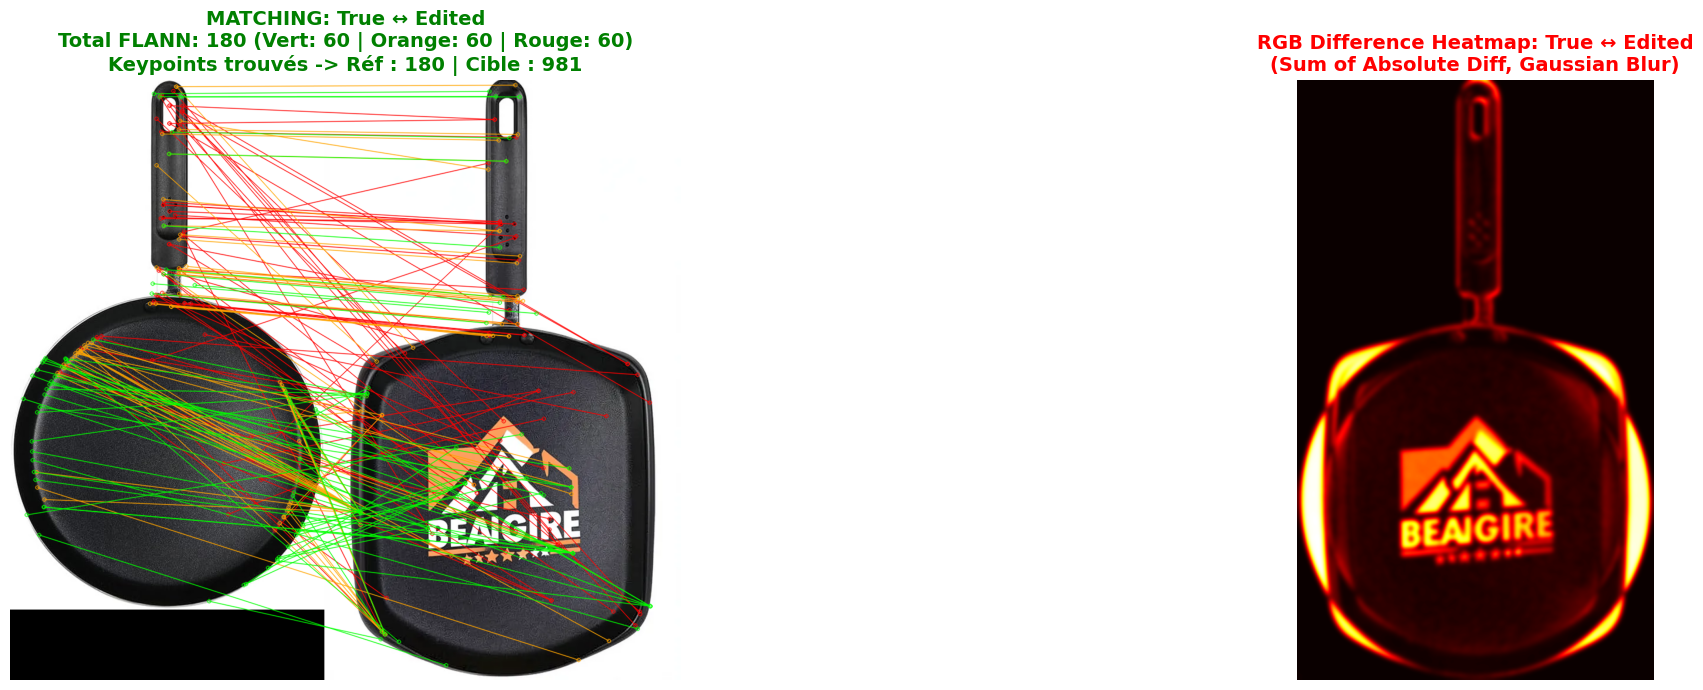

In [ ]:
def draw_sift_flann(ax, img1_path, img2_path, title, color_title):
    """Dessine tous les points SIFT avec le moteur FLANN et un code couleur (Vert/Orange/Rouge)."""
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0, None, None

    # 1. Lecture des images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0, img1, img2

    # 2. Conversion et SIFT
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    # Sécurité FLANN : s'assurer qu'il y a assez de points pour comparer
    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés", ha='center', va='center', color='red')
        ax.axis('off')
        return 0, img1, img2

    # 3.CONFIGURATION FLANN
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 50) # Plus le chiffre est haut, plus c'est précis mais lent

    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # 4. Matching et Tri (du meilleur au pire)
    matches = flann.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    total_matches = len(matches)

    if total_matches == 0:
        ax.axis('off')
        return 0, img1, img2

    # 5. Découpage en 3 tiers (Top 33%, Milieu 33%, Bas 33%)
    tier1 = total_matches // 3
    tier2 = 2 * (total_matches // 3)

    good_matches = matches[:tier1]         # Les meilleurs
    medium_matches = matches[tier1:tier2]  # Les moyens
    bad_matches = matches[tier2:]          # Les pires

    # 6. Dessin par couches successives (Rouge au fond, Vert devant)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, bad_matches, None,
                                 matchColor=(0, 0, 255), # Rouge BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_result = cv2.drawMatches(img1, kp1, img2, kp2, medium_matches, img_result,
                                 matchColor=(0, 165, 255), # Orange BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, img_result,
                                 matchColor=(0, 255, 0), # Vert BGR
                                 flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # 7. Affichage Matplotlib
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"Total FLANN: {total_matches} (Vert: {len(good_matches)} | Orange: {len(medium_matches)} | Rouge: {len(bad_matches)})\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return total_matches, img1, img2

def sift_explorer_flann(index):
    file_id = all_ids[index]

    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # On crée 2 colonnes pour FLANN Matching et Heatmap
    fig, axes = plt.subplots(1, 2, figsize=(28, 7))

    # Plot 1: FLANN SIFT Matching (True <-> Edited)
    total_matches, img_true_cv_orig, img_edited_cv_orig = draw_sift_flann(axes[0], path_t, path_e, "MATCHING: True ↔ Edited", "green")

    # Plot 2: Heatmap of RGB difference (True <-> Edited)
    if path_t and path_e: # Check if paths exist
        if img_true_cv_orig is not None and img_edited_cv_orig is not None:
            # Resize edited_img to match true_img dimensions
            height, width, _ = img_true_cv_orig.shape
            img_edited_resized = cv2.resize(img_edited_cv_orig, (width, height))

            # Convert to RGB (OpenCV reads as BGR)
            img_true_rgb = cv2.cvtColor(img_true_cv_orig, cv2.COLOR_BGR2RGB)
            img_edited_rgb = cv2.cvtColor(img_edited_resized, cv2.COLOR_BGR2RGB)

            # Calculate absolute difference and sum across color channels
            diff_map = np.sum(np.abs(img_true_rgb.astype(np.float32) - img_edited_rgb.astype(np.float32)), axis=2)

            # Apply Gaussian blur to the difference map for smoother visualization
            diff_map_blurred = cv2.GaussianBlur(diff_map, (21, 21), 0)

            axes[1].imshow(diff_map_blurred, cmap='hot')
            axes[1].set_title("RGB Difference Heatmap: True ↔ Edited\n(Sum of Absolute Diff, Gaussian Blur)", fontsize=14, color="red", fontweight='bold')
            axes[1].axis('off')
        else:
            axes[1].text(0.5, 0.5, f"Could not load images for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
            axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, f"Missing files for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close(fig) # Close the combined figure

# Lancement du widget
if all_ids:
    widgets.interact(sift_explorer_flann, index=widgets.IntSlider(min=0, max=len(all_ids)-1, value=0, description='Analyser ID:'))

b. RomaV2 Heatmap ne veux pas ce mettre laa ca fait bcp de bug

YAHIA J'arrive pas a mettre la heatmap a cote (a drodes paires la, essaye de le faire mais c'est pas grave si t'arrives pas

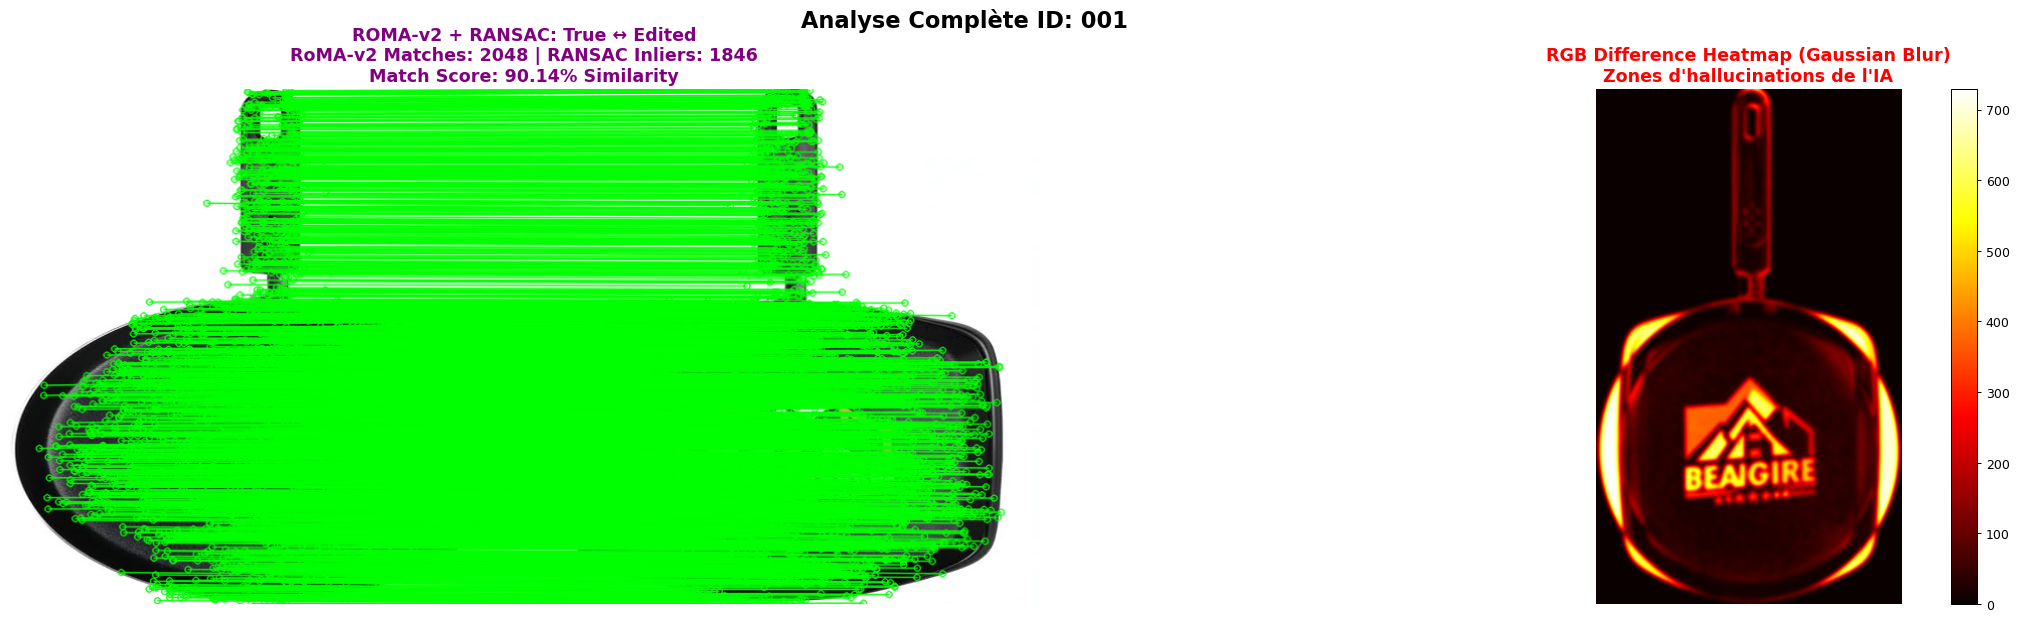

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import torch
import gc
import traceback
from vismatch import get_matcher

# Ajustement pour éviter que l'image soit trop géante à l'écran
matplotlib.rcParams['figure.dpi'] = 90

# Initialisation du modèle
try:
    matcher
except NameError:
    matcher = get_matcher("romav2", device="cuda")

def generate_heatmap(img_a_cv, img_b_cv):
    """Génère la heatmap de différence RGB avec un flou gaussien."""
    h, w, _ = img_a_cv.shape
    img_b_resized = cv2.resize(img_b_cv, (w, h))

    img_a_rgb = cv2.cvtColor(img_a_cv, cv2.COLOR_BGR2RGB).astype(np.float32)
    img_b_rgb = cv2.cvtColor(img_b_resized, cv2.COLOR_BGR2RGB).astype(np.float32)

    diff = np.sum(np.abs(img_a_rgb - img_b_rgb), axis=2)
    return cv2.GaussianBlur(diff, (21, 21), 0)

def draw_romav2_cv2_ransac(ax, img1_path, img2_path, title, color_title):
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0.0, None, None

    # 1. Chargement pur OpenCV (le format le plus stable, pour la Heatmap)
    img1_cv_orig = cv2.imread(img1_path)
    img2_cv_orig = cv2.imread(img2_path)

    # 2. Chargement IA pour extraction des points (512x512)
    img1_roma = matcher.load_image(img1_path, resize=512)
    img2_roma = matcher.load_image(img2_path, resize=512)

    with torch.no_grad():
        result = matcher(img1_roma, img2_roma)

    pts_A = np.array(result["matched_kpts0"])
    pts_B = np.array(result["matched_kpts1"])
    total_kp = len(pts_A)

    if total_kp < 4:
        ax.text(0.5, 0.5, "Pas assez de points", ha='center', color='red')
        ax.axis('off')
        return 0.0, img1_cv_orig, img2_cv_orig

    # 3. RANSAC
    M, mask = cv2.findHomography(pts_A, pts_B, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist() if mask is not None else [0] * total_kp

    # 4. L'ASTUCE ULTIME : On redimensionne l'image OpenCV pour dessiner !
    # Ça évite totalement de devoir décoder les tenseurs complexes de PyTorch
    img1_draw = cv2.resize(img1_cv_orig, (512, 512))
    img2_draw = cv2.resize(img2_cv_orig, (512, 512))

    kp1 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=1) for p in pts_A]
    kp2 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=1) for p in pts_B]

    inlier_matches = [cv2.DMatch(_queryIdx=i, _trainIdx=i, _distance=0) for i in range(total_kp) if matches_mask[i]]

    nb_inliers = len(inlier_matches)
    match_percentage = (nb_inliers / total_kp * 100) if total_kp > 0 else 0.0

    # 5. Dessin (Exactement comme ton code SIFT qui marchait !)
    img_result = cv2.drawMatches(img1_draw, kp1, img2_draw, kp2, inlier_matches, None,
                                 matchColor=(0, 255, 0), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.set_title(f"{title}\nRoMA-v2 Matches: {total_kp} | RANSAC Inliers: {nb_inliers}", fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')

    del result, img1_roma, img2_roma
    gc.collect()
    torch.cuda.empty_cache()

    return match_percentage, img1_cv_orig, img2_cv_orig

# --- MISE EN PLACE DE L'INTERFACE INTERACTIVE ---
if all_ids:
    slider = widgets.IntSlider(min=0, max=len(all_ids)-1, step=1, value=0, description='Image ID:', layout={'width': '600px'})
    out = widgets.Output()

    def show_result(index):
        with out:
            clear_output(wait=True) # Évite la double scrollbar de Colab
            img_id = all_ids[index]

            path_t = os.path.join(folders['true'], true_map.get(img_id)) if true_map.get(img_id) else None
            path_e = os.path.join(folders['ai'], ai_map.get(img_id)) if ai_map.get(img_id) else None

            if not path_t or not path_e:
                print(f"Fichiers manquants pour l'ID {img_id}")
                return

            try:
                fig_combine, axes = plt.subplots(1, 2, figsize=(24, 7))

                # Colonne 1 : L'image des matchs RoMA + RANSAC
                match_percentage, img_true_cv, img_edited_cv = draw_romav2_cv2_ransac(axes[0], path_t, path_e, "ROMA-v2 + RANSAC: True ↔ Edited", "purple")

                if match_percentage > 0:
                    axes[0].set_title(axes[0].get_title() + f"\nMatch Score: {match_percentage:.2f}% Similarity", fontsize=14, color="purple", fontweight='bold')

                # Colonne 2 : La Heatmap
                if img_true_cv is not None and img_edited_cv is not None:
                    heatmap = generate_heatmap(img_true_cv, img_edited_cv)
                    im_h = axes[1].imshow(heatmap, cmap='hot')
                    axes[1].set_title("RGB Difference Heatmap (Gaussian Blur)\nZones d'hallucinations de l'IA", fontsize=14, color="red", fontweight='bold')
                    axes[1].axis('off')
                    plt.colorbar(im_h, ax=axes[1], fraction=0.046, pad=0.04)

                plt.suptitle(f"Analyse Complète ID: {img_id}", fontsize=18, fontweight='bold')
                plt.tight_layout()
                plt.show()
                plt.close(fig_combine)

            except Exception as e:
                # S'il y a une erreur, elle s'affichera au lieu d'être avalée par le output !
                print(f"Erreur fatale lors de l'affichage : {e}")
                traceback.print_exc()

    slider.observe(lambda change: show_result(change['new']), names='value')
    display(widgets.VBox([slider, out]))
    show_result(0)

c. RANSAC (BruteForce then FLANN)

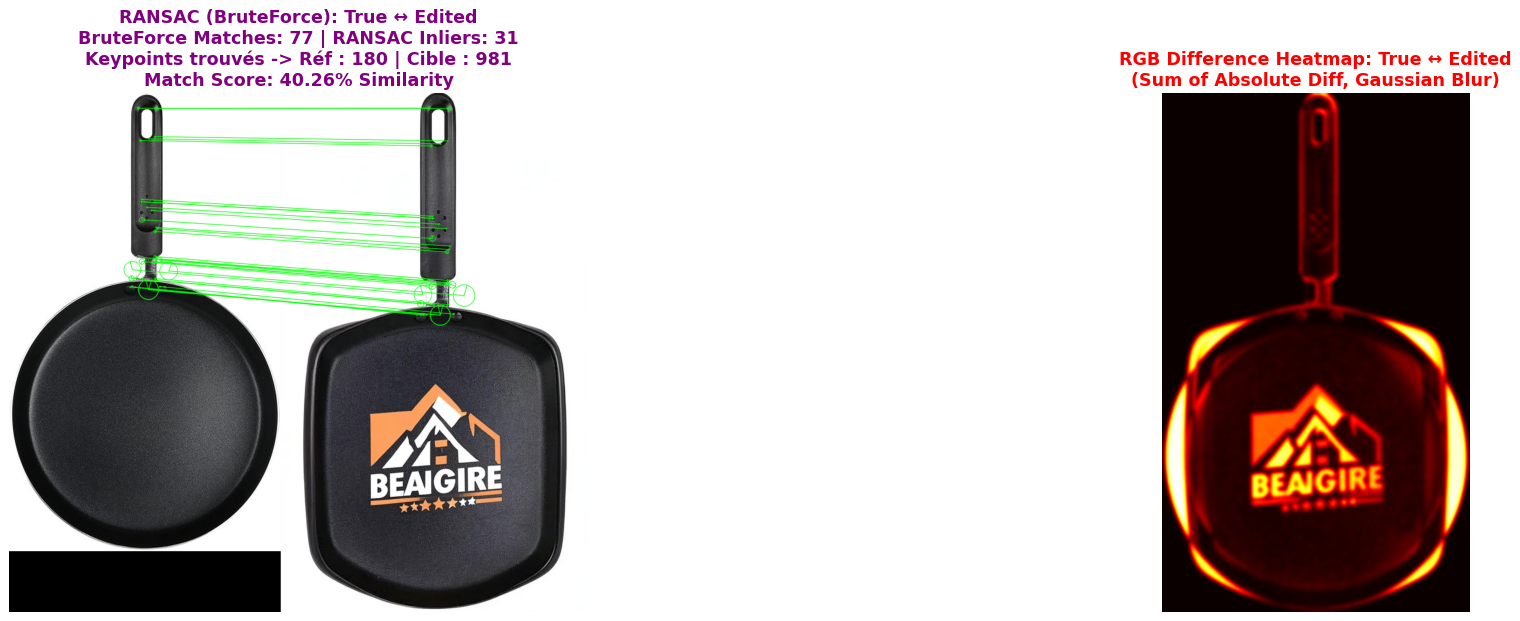

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os

# SIFT detector and BFMatcher are already initialized in cell lH4B8Kt6kJJA
# sift = cv2.SIFT_create()
# bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

def draw_sift_bruteforce_ransac(ax, img1_path, img2_path, title, color_title):
    """Dessine les points SIFT appariés avec BruteForce et filtrés par RANSAC.
    Retourne le pourcentage d'inliers RANSAC, et les images lues.
    """
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0.0, None, None

    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0.0, img1, img2

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés pour RANSAC", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0, img1, img2

    # Perform Brute-Force matching (with crossCheck=True for initial good matches)
    initial_matches = bf.match(des1, des2)

    if len(initial_matches) < 4: # RANSAC requires at least 4 points
        ax.text(0.5, 0.5, f"Pas assez de bons matchs ({len(initial_matches)}) pour RANSAC", ha='center', va='center', color='orange')
        ax.axis('off')
        return 0.0, img1, img2

    # Extract keypoints for RANSAC from initial_matches
    src_pts = np.float32([kp1[m.queryIdx].pt for m in initial_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in initial_matches]).reshape(-1, 1, 2)

    # Find Homography and RANSAC mask
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist()

    # Filter initial_matches using the RANSAC mask to get inliers
    inlier_matches = [m for i, m in enumerate(initial_matches) if matches_mask[i]]

    if len(inlier_matches) == 0:
        ax.text(0.5, 0.5, "Aucun inlier RANSAC trouvé", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0, img1, img2

    # Calculate percentage
    match_percentage = (len(inlier_matches) / len(initial_matches)) * 100 if len(initial_matches) > 0 else 0.0

    # Draw only inlier matches (green color)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, inlier_matches, None,
                                 matchColor=(0, 255, 0), # Green BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS | cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"BruteForce Matches: {len(initial_matches)} | RANSAC Inliers: {len(inlier_matches)}\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return match_percentage, img1, img2

def sift_bruteforce_ransac_explorer(index):
    file_id = all_ids[index]

    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # Create two subplots: one for RANSAC, one for heatmap
    fig, axes = plt.subplots(1, 2, figsize=(28, 7)) # Increased figsize for two plots

    # Plot 1: RANSAC results
    match_percentage, img_true_cv_orig, img_edited_cv_orig = draw_sift_bruteforce_ransac(axes[0], path_t, path_e, "RANSAC (BruteForce): True ↔ Edited", "green") # Changed title and color_title and path_r to path_t

    if match_percentage > 0:
        current_title = axes[0].get_title()
        axes[0].set_title(f"{current_title}\nMatch Score: {match_percentage:.2f}% Similarity", fontsize=14, color="purple", fontweight='bold')
    elif match_percentage == 0:
        current_title = axes[0].get_title()
        if "Aucun inlier RANSAC trouvé" not in current_title and "Pas assez de bons matchs" not in current_title:
             axes[0].set_title(f"{current_title}\nMatch Score: 0.00% Similarity", fontsize=14, color="purple", fontweight='bold')

    # Plot 2: Heatmap of RGB difference
    if path_t and path_e: # Check if paths exist
        if img_true_cv_orig is not None and img_edited_cv_orig is not None:
            # Resize edited_img to match true_img dimensions
            height, width, _ = img_true_cv_orig.shape
            img_edited_resized = cv2.resize(img_edited_cv_orig, (width, height))

            # Convert to RGB (OpenCV reads as BGR)
            img_true_rgb = cv2.cvtColor(img_true_cv_orig, cv2.COLOR_BGR2RGB)
            img_edited_rgb = cv2.cvtColor(img_edited_resized, cv2.COLOR_BGR2RGB)

            # Calculate absolute difference and sum across color channels
            diff_map = np.sum(np.abs(img_true_rgb.astype(np.float32) - img_edited_rgb.astype(np.float32)), axis=2)

            # Apply Gaussian blur to the difference map for smoother visualization
            diff_map_blurred = cv2.GaussianBlur(diff_map, (21, 21), 0)

            axes[1].imshow(diff_map_blurred, cmap='hot')
            axes[1].set_title("RGB Difference Heatmap: True ↔ Edited\n(Sum of Absolute Diff, Gaussian Blur)", fontsize=14, color="red", fontweight='bold')
            axes[1].axis('off')
        else:
            axes[1].text(0.5, 0.5, f"Could not load images for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
            axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, f"Missing files for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(sift_bruteforce_ransac_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Analyser ID (BruteForce+RANSAC):',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))
else:
    print("No image IDs found to create the slider.")

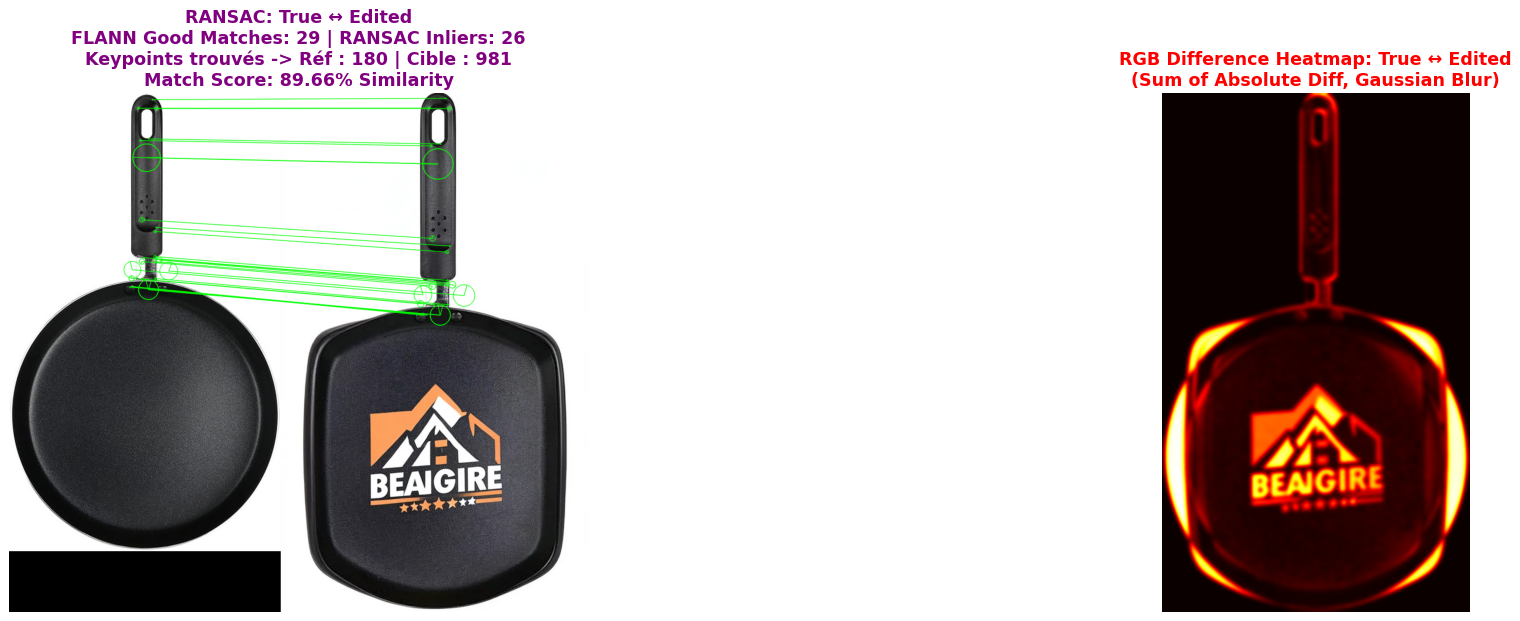

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os

# SIFT detector is already initialized in cell lH4B8Kt6kJJA
# sift = cv2.SIFT_create()

def draw_sift_flann_ransac(ax, img1_path, img2_path, title, color_title):
    """Dessine les points SIFT appariés avec FLANN et filtrés par RANSAC.
    Retourne le pourcentage d'inliers RANSAC, et les images lues.
    """
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0.0, None, None

    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        ax.axis('off')
        return 0.0, img1, img2

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    nb_kp1 = len(kp1) if kp1 is not None else 0
    nb_kp2 = len(kp2) if kp2 is not None else 0

    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        ax.text(0.5, 0.5, "Pas assez de points trouvés pour RANSAC", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0, img1, img2

    # FLANN parameters
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des1, des2, k=2)

    # Apply ratio test (Lowe's ratio test)
    good_matches = []
    if matches:
        for m, n in matches:
            if m.distance < 0.7 * n.distance:
                good_matches.append(m)

    if len(good_matches) < 4: # RANSAC requires at least 4 points
        ax.text(0.5, 0.5, f"Pas assez de bons matchs ({len(good_matches)}) pour RANSAC", ha='center', va='center', color='orange')
        ax.axis('off')
        return 0.0, img1, img2

    # Extract keypoints for RANSAC
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Find Homography and RANSAC mask
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist()

    # Filter good matches using the RANSAC mask
    inlier_matches = [m for i, m in enumerate(good_matches) if matches_mask[i]]

    if len(inlier_matches) == 0:
        ax.text(0.5, 0.5, "Aucun inlier RANSAC trouvé", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0, img1, img2

    # Calculate percentage
    match_percentage = (len(inlier_matches) / len(good_matches)) * 100 if len(good_matches) > 0 else 0.0

    # Draw only inlier matches (green color)
    img_result = cv2.drawMatches(img1, kp1, img2, kp2, inlier_matches, None,
                                 matchColor=(0, 255, 0), # Green BGR
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS | cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"FLANN Good Matches: {len(good_matches)} | RANSAC Inliers: {len(inlier_matches)}\n"
                     f"Keypoints trouvés -> Réf : {nb_kp1} | Cible : {nb_kp2}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')
    return match_percentage, img1, img2

def ransac_explorer(index):
    file_id = all_ids[index]

    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # Create two subplots: one for RANSAC, one for heatmap
    fig, axes = plt.subplots(1, 2, figsize=(28, 7)) # Increased figsize for two plots

    # Plot 1: RANSAC results
    match_percentage, img_true_cv_orig, img_edited_cv_orig = draw_sift_flann_ransac(axes[0], path_t, path_e, "RANSAC: True \u2194 Edited", "green")

    if match_percentage > 0:
        current_title = axes[0].get_title()
        axes[0].set_title(f"{current_title}\nMatch Score: {match_percentage:.2f}% Similarity", fontsize=14, color="purple", fontweight='bold')
    elif match_percentage == 0:
        current_title = axes[0].get_title()
        if "Aucun inlier RANSAC trouvé" not in current_title and "Pas assez de bons matchs" not in current_title:
             axes[0].set_title(f"{current_title}\nMatch Score: 0.00% Similarity", fontsize=14, color="purple", fontweight='bold')

    # Plot 2: Heatmap of RGB difference
    if path_t and path_e: # Check if paths exist
        if img_true_cv_orig is not None and img_edited_cv_orig is not None:
            # Resize edited_img to match true_img dimensions
            height, width, _ = img_true_cv_orig.shape
            img_edited_resized = cv2.resize(img_edited_cv_orig, (width, height))

            # Convert to RGB (OpenCV reads as BGR)
            img_true_rgb = cv2.cvtColor(img_true_cv_orig, cv2.COLOR_BGR2RGB)
            img_edited_rgb = cv2.cvtColor(img_edited_resized, cv2.COLOR_BGR2RGB)

            # Calculate absolute difference and sum across color channels
            diff_map = np.sum(np.abs(img_true_rgb.astype(np.float32) - img_edited_rgb.astype(np.float32)), axis=2)

            # Apply Gaussian blur to the difference map for smoother visualization
            diff_map_blurred = cv2.GaussianBlur(diff_map, (21, 21), 0)

            axes[1].imshow(diff_map_blurred, cmap='hot')
            axes[1].set_title("RGB Difference Heatmap: True \u2194 Edited\n(Sum of Absolute Diff, Gaussian Blur)", fontsize=14, color="red", fontweight='bold')
            axes[1].axis('off')
        else:
            axes[1].text(0.5, 0.5, f"Could not load images for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
            axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, f"Missing files for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(ransac_explorer,
                    index=widgets.IntSlider(
                        min=0,
                        max=len(all_ids)-1,
                        step=1,
                        value=0,
                        description='Image ID:',
                        style={'description_width': 'initial'},
                        layout={'width': '600px'}
                    ))
else:
    print("No image IDs found to create the slider.")

YAHIA APPLIQUE RANSAC SUR LES PAIRES TRUE, EDIT AVEC LA METHODE ROMAV2 ET sur le cote des paires mets la heatmap avec gaussian blur comme la celle juste au dessus

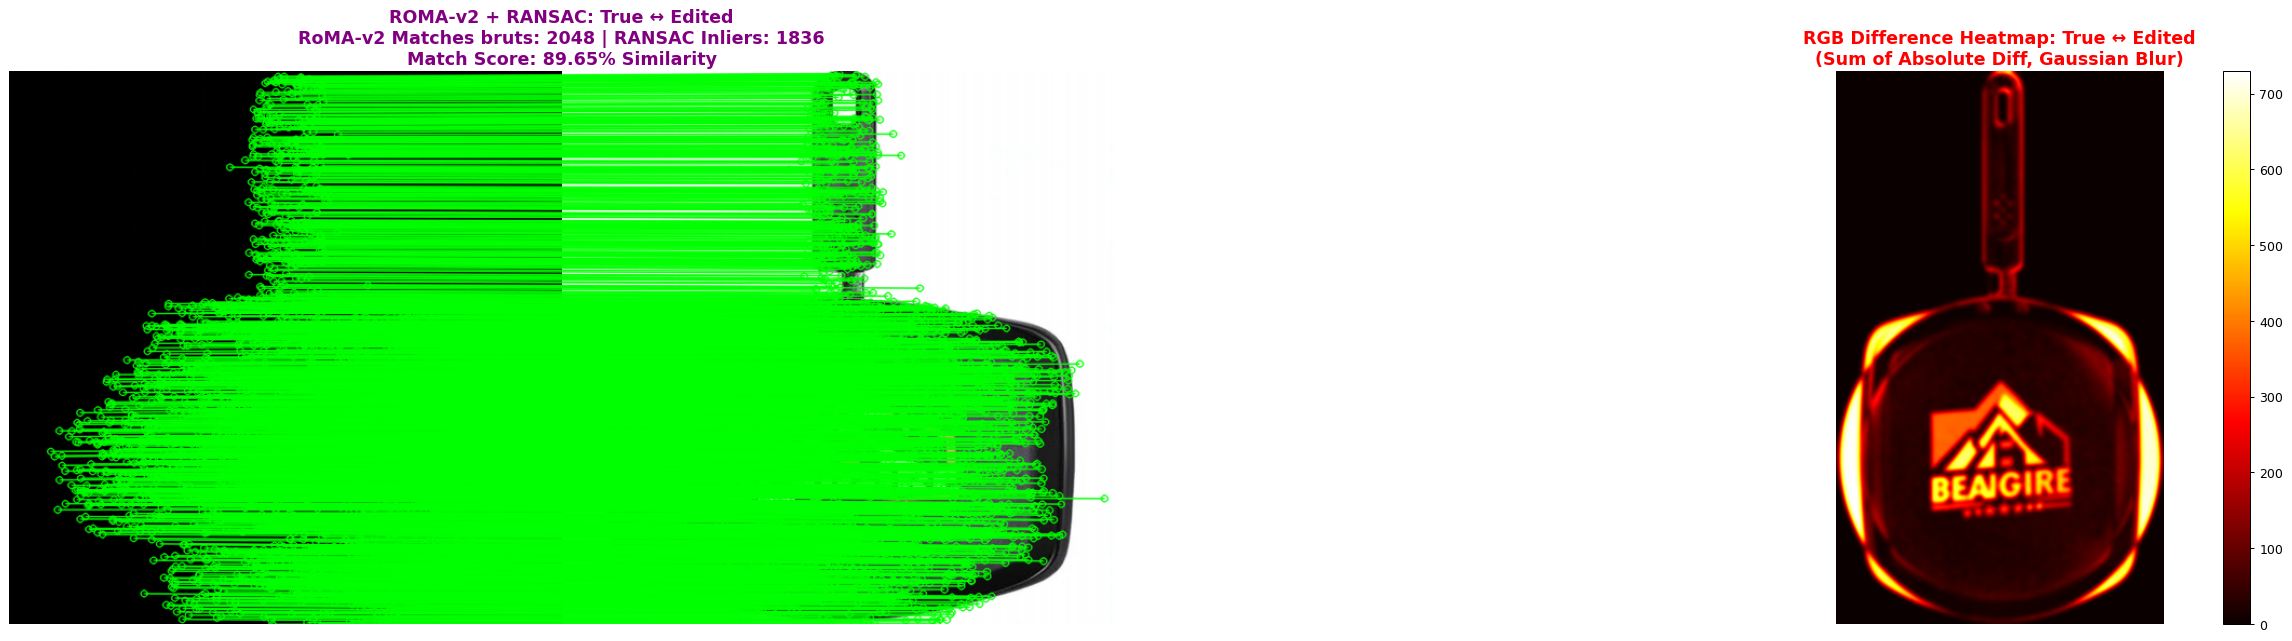

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os
import torch
import gc
from vismatch import get_matcher

# Chargement du modèle RoMA-v2 (s'il n'est pas déjà chargé)
try:
    matcher
except NameError:
    matcher = get_matcher("romav2", device="cuda")

def draw_romav2_cv2_ransac(ax, img1_path, img2_path, title, color_title):
    """Dessine les points RoMA-v2 filtrés par RANSAC en utilisant OpenCV.
    Retourne le pourcentage d'inliers, et les images originales pour la heatmap.
    """
    if not img1_path or not img2_path:
        ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        ax.axis('off')
        return 0.0, None, None

    # 1. Chargement des images originales pour la Heatmap
    img1_cv_orig = cv2.imread(img1_path)
    img2_cv_orig = cv2.imread(img2_path)
    if img1_cv_orig is None or img2_cv_orig is None:
        ax.axis('off')
        return 0.0, img1_cv_orig, img2_cv_orig

    # 2. Chargement des images pour RoMA-v2
    img1_roma = matcher.load_image(img1_path, resize=512)
    img2_roma = matcher.load_image(img2_path, resize=512)

    # 3. Exécution de RoMA-v2
    with torch.no_grad():
        result = matcher(img1_roma, img2_roma)

    pts_A = np.array(result["matched_kpts0"])
    pts_B = np.array(result["matched_kpts1"])
    total_kp = len(pts_A)

    if total_kp < 4:
        ax.text(0.5, 0.5, f"Pas assez de points trouvés par RoMA ({total_kp})", ha='center', va='center', color='red')
        ax.axis('off')
        return 0.0, img1_cv_orig, img2_cv_orig

    # 4. Calcul de l'homographie et masque RANSAC
    M, mask = cv2.findHomography(pts_A, pts_B, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist() if mask is not None else [0] * total_kp

    # 5. CORRECTION : Conversion du tenseur PyTorch en image OpenCV lisible
    def tensor_to_cv2(tensor_img):
        # On enlève les dimensions inutiles et on récupère le tableau
        arr = tensor_img.squeeze().cpu().numpy()
        # Si le tableau est [Couleurs, H, W], on le transpose en [H, W, Couleurs]
        if arr.shape[0] == 3:
            arr = np.transpose(arr, (1, 2, 0))
        # Si l'image est normalisée entre 0 et 1, on la passe en 0-255
        if arr.max() <= 1.0:
            arr = (arr * 255).astype(np.uint8)
        else:
            arr = arr.astype(np.uint8)
        # On convertit de RGB (PyTorch) vers BGR (OpenCV)
        return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)

    img1_draw = tensor_to_cv2(img1_roma)
    img2_draw = tensor_to_cv2(img2_roma)

    kp1 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=1) for p in pts_A]
    kp2 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=1) for p in pts_B]

    inlier_matches = []
    for i in range(total_kp):
        if matches_mask[i]:
            # Faux match OpenCV pour dessiner la ligne de l'inlier
            inlier_matches.append(cv2.DMatch(_queryIdx=i, _trainIdx=i, _distance=0))

    nb_inliers = len(inlier_matches)
    match_percentage = (nb_inliers / total_kp * 100) if total_kp > 0 else 0.0

    # 6. Dessin des lignes vertes avec OpenCV
    img_result = cv2.drawMatches(img1_draw, kp1, img2_draw, kp2, inlier_matches, None,
                                 matchColor=(0, 255, 0),
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    titre_complet = (f"{title}\n"
                     f"RoMA-v2 Matches bruts: {total_kp} | RANSAC Inliers: {nb_inliers}")

    ax.imshow(img_rgb)
    ax.set_title(titre_complet, fontsize=14, color=color_title, fontweight='bold')
    ax.axis('off')

    # Nettoyage mémoire
    del result, img1_roma, img2_roma
    gc.collect()
    torch.cuda.empty_cache()

    return match_percentage, img1_cv_orig, img2_cv_orig


def romav2_true_edit_heatmap_explorer(index):
    file_id = all_ids[index]

    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    # Création des 2 colonnes
    fig, axes = plt.subplots(1, 2, figsize=(28, 7))

    # Colonne 1: RANSAC results avec RoMA-v2
    match_percentage, img_true_cv_orig, img_edited_cv_orig = draw_romav2_cv2_ransac(axes[0], path_t, path_e, "ROMA-v2 + RANSAC: True ↔ Edited", "purple")

    if match_percentage > 0:
        current_title = axes[0].get_title()
        axes[0].set_title(f"{current_title}\nMatch Score: {match_percentage:.2f}% Similarity", fontsize=14, color="purple", fontweight='bold')
    elif match_percentage == 0:
        current_title = axes[0].get_title()
        if "Aucun inlier RANSAC trouvé" not in current_title and "Pas assez de points" not in current_title:
             axes[0].set_title(f"{current_title}\nMatch Score: 0.00% Similarity", fontsize=14, color="purple", fontweight='bold')

    # Colonne 2: Heatmap of RGB difference
    if path_t and path_e:
        if img_true_cv_orig is not None and img_edited_cv_orig is not None:
            height, width, _ = img_true_cv_orig.shape
            img_edited_resized = cv2.resize(img_edited_cv_orig, (width, height))

            img_true_rgb = cv2.cvtColor(img_true_cv_orig, cv2.COLOR_BGR2RGB)
            img_edited_rgb = cv2.cvtColor(img_edited_resized, cv2.COLOR_BGR2RGB)

            diff_map = np.sum(np.abs(img_true_rgb.astype(np.float32) - img_edited_rgb.astype(np.float32)), axis=2)
            diff_map_blurred = cv2.GaussianBlur(diff_map, (21, 21), 0)

            im_h = axes[1].imshow(diff_map_blurred, cmap='hot')
            axes[1].set_title("RGB Difference Heatmap: True ↔ Edited\n(Sum of Absolute Diff, Gaussian Blur)", fontsize=14, color="red", fontweight='bold')
            axes[1].axis('off')
            plt.colorbar(im_h, ax=axes[1], fraction=0.046, pad=0.04)
        else:
            axes[1].text(0.5, 0.5, f"Could not load images for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
            axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, f"Missing files for Heatmap\nID: {file_id}", ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Launch the interactive slider
if all_ids:
    widgets.interact(romav2_true_edit_heatmap_explorer,
                     index=widgets.IntSlider(
                         min=0, max=len(all_ids)-1, step=1, value=0,
                         description='Analyser ID (RoMA-v2):', style={'description_width': 'initial'}, layout={'width': '600px'}
                     ))
else:
    print("No image IDs found to create the slider.")

4. Forward Backwards Method

In [ ]:
import torch
import numpy as np
from scipy.spatial import cKDTree

def evaluate_cycle_consistency(matcher, img_ref, img_edited, threshold=3.0):
    """
    Calcule le score de fiabilité (Cycle Consistency) entre deux images.

    Args:
        matcher: Le modèle RoMaV2 initialisé.
        img_ref: L'image de référence (True).
        img_edited: L'image modifiée (Edited).
        threshold: Tolérance en pixels pour considérer un point comme "fiable".

    Returns:
        score_pourcentage: % de l'image qui est fiable/non-éditée.
        erreur_moyenne: L'erreur de retour moyenne en pixels.
    """
    print("Étape 1 : Calcul du trajet Aller (Ref -> Edited)...")
    with torch.no_grad():
        res_fwd = matcher(img_ref, img_edited)

    # Points de départ (A) et d'arrivée (B)
    pts_A_fwd = res_fwd["matched_kpts0"]
    pts_B_fwd = res_fwd["matched_kpts1"]

    # --- NETTOYAGE MÉMOIRE STRICT ---
    del res_fwd
    gc.collect()
    torch.cuda.empty_cache()

    print("Étape 2 : Calcul du trajet Retour (Edited -> Ref)...")
    with torch.no_grad():
        res_bwd = matcher(img_edited, img_ref)

    # Points de départ (B) et d'arrivée (A) pour le retour
    pts_B_bwd = res_bwd["matched_kpts0"]
    pts_A_bwd = res_bwd["matched_kpts1"]

    # --- NETTOYAGE MÉMOIRE STRICT ---
    del res_bwd
    gc.collect()
    torch.cuda.empty_cache()

    print("Étape 3 : Analyse de la cohérence spatiale...")
    # 1. Arbre de recherche sur les points B du retour
    tree = cKDTree(pts_B_bwd)
    distances_B, indices_B = tree.query(pts_B_fwd, k=1)

    # 2. Point d'arrivée final dans A
    pts_A_final = pts_A_bwd[indices_B]

    # 3.  Erreur est UNIQUEMENT la distance entre le départ A et l'arrivée A
    erreurs_cycle = np.linalg.norm(pts_A_fwd - pts_A_final, axis=1)

    # 4. Pour qu'un point soit valide, il faut :
    # - Que le point relais dans B ne soit pas absurde (ex: < 15 pixels d'écart)
    # - Que l'erreur de retour dans A soit sous ton seuil de 3.0 pixels
    points_fiables = (distances_B < 15.0) & (erreurs_cycle <= threshold)

    # 5. Calcul final
    score_pourcentage = np.mean(points_fiables) * 100

    # On calcule l'erreur moyenne uniquement sur les points qui ont pu faire l'aller-retour
    erreur_moyenne = np.mean(erreurs_cycle[distances_B < 15.0])

    return score_pourcentage, erreur_moyenne

In [ ]:
import cv2
import numpy as np
from scipy.spatial import cKDTree # Added for SIFT spatial cycle consistency
# --- New functions for SIFT Cycle Consistency ---
def calculate_sift_cycle_consistency_score(imgA_path, imgB_path, lowe_threshold=0.75, spatial_threshold=3.0):
    """
    Calculates Forward-Backward Cycle Consistency for SIFT (BruteForce only),
    returning a percentage of spatially consistent matches and the average cycle error.
    """
    if not imgA_path or not imgB_path:
        return 0.0, 0.0

    imgA = cv2.imread(imgA_path, cv2.IMREAD_GRAYSCALE)
    imgB = cv2.imread(imgB_path, cv2.IMREAD_GRAYSCALE)
    if imgA is None or imgB is None:
        return 0.0, 0.0

    kp1, des1 = sift.detectAndCompute(imgA, None)
    kp2, des2 = sift.detectAndCompute(imgB, None)

    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        return 0.0, 0.0

    # BruteForce Matcher Setup
    sift_matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

    # --- Forward Pass (A -> B) ---
    matches_AB = sift_matcher.knnMatch(des1, des2, k=2)
    good_AB_matches = []
    if matches_AB:
        for m_n in matches_AB:
            if len(m_n) == 2:
                m, n = m_n
                if m.distance < lowe_threshold * n.distance:
                    good_AB_matches.append(m)

    if not good_AB_matches:
        return 0.0, 0.0

    pts_A_fwd = np.float32([kp1[m.queryIdx].pt for m in good_AB_matches])
    pts_B_fwd = np.float32([kp2[m.trainIdx].pt for m in good_AB_matches])

    # --- Backward Pass (B -> A) ---
    matches_BA = sift_matcher.knnMatch(des2, des1, k=2)
    good_BA_matches = []
    if matches_BA:
        for m_n in matches_BA:
            if len(m_n) == 2:
                m, n = m_n
                if m.distance < lowe_threshold * n.distance:
                    good_BA_matches.append(m)

    if not good_BA_matches:
        return 0.0, 0.0

    pts_B_bwd = np.float32([kp2[m.queryIdx].pt for m in good_BA_matches])
    pts_A_bwd = np.float32([kp1[m.trainIdx].pt for m in good_BA_matches])

    # --- Cycle Consistency Check (A -> B -> A) ---
    # For each (pts_A_fwd[i], pts_B_fwd[i]) pair, find pts_B_fwd[i] within pts_B_bwd
    # and then get the corresponding pts_A_bwd point.

    # Use cKDTree for efficient spatial lookup of B_fwd points within B_bwd points
    tree = cKDTree(pts_B_bwd)
    distances_to_B_bwd, indices_in_B_bwd = tree.query(pts_B_fwd, k=1)

    # Get the reconstructed A points from the backward pass, based on the closest B_bwd point
    pts_A_reconstructed = pts_A_bwd[indices_in_B_bwd]

    # Calculate the cycle error: distance between original A and reconstructed A
    cycle_errors = np.linalg.norm(pts_A_fwd - pts_A_reconstructed, axis=1)

    # Filter by a small distance for the B->B correspondence to avoid spurious matches
    # This acts similarly to the 'distances_B < 15.0' filtering in the RoMaV2 function
    valid_cycle_mask = (distances_to_B_bwd < 15.0) # Check if B_fwd is close enough to a B_bwd point

    if not np.any(valid_cycle_mask): # No valid cycles found after filtering B->B distance
        return 0.0, 0.0

    # Filter cycle errors based on valid_cycle_mask
    filtered_cycle_errors = cycle_errors[valid_cycle_mask]

    if not filtered_cycle_errors.size: # No valid cycle errors after filtering
        return 0.0, 0.0

    # Calculate percentage of spatially consistent matches (within spatial_threshold)
    spatially_consistent_count = np.sum(filtered_cycle_errors <= spatial_threshold)
    percentage_spatially_consistent = (spatially_consistent_count / filtered_cycle_errors.size) * 100

    # Calculate average error for *all* valid cycle-consistent matches (that passed the B->B distance check)
    average_cycle_error = np.mean(filtered_cycle_errors)

    return percentage_spatially_consistent, average_cycle_error

def cycle_consistency_sift_explorer(index, spatial_threshold_value=3.0):
    """
    Interactive explorer for SIFT BruteForce cycle consistency scores (with spatial error).
    """
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    print(f"--- BruteForce SIFT Cycle Consistency Scores (Spatial) for Image ID: {file_id} ---")

    # Ref <-> True
    print("\nPair: Reference <-> True")
    if path_r and path_t:
        percentage_rt, _ = calculate_sift_cycle_consistency_score(path_r, path_t, spatial_threshold=spatial_threshold_value)
        print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_rt:.2f}%")
    else:
        print("  Missing Reference or True image.")

    # Ref <-> Edited
    print("\nPair: Reference <-> Edited")
    if path_r and path_e:
        percentage_re, _ = calculate_sift_cycle_consistency_score(path_r, path_e, spatial_threshold=spatial_threshold_value)
        print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_re:.2f}%")
    else:
        print("  Missing Reference or Edited image.")

    # True <-> Edited
    print("\nPair: True <-> Edited")
    if path_t and path_e:
        percentage_te, _ = calculate_sift_cycle_consistency_score(path_t, path_e, spatial_threshold=spatial_threshold_value)
        print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_te:.2f}%")
    else:
        print("  Missing True or Edited image.")

# Launch the interactive slider for SIFT Cycle Consistency
print("\n--- SIFT Cycle Consistency Explorer (BruteForce) ---")
if all_ids:
    widgets.interact(cycle_consistency_sift_explorer,
                     index=widgets.IntSlider(
                         min=0,
                         max=len(all_ids)-1,
                         step=1,
                         value=0,
                         description='Image ID (SIFT BruteForce CC):',
                         style={'description_width': 'initial'},
                         layout={'width': '600px'}
                     ),
                     spatial_threshold_value=widgets.FloatSlider(
                         min=0.5,
                         max=20.0, # Increased max value to allow more flexibility
                         step=0.5,
                         value=3.0,
                         description='Spatial Threshold (px):',
                         style={'description_width': 'initial'},
                         layout={'width': '600px'}
                     ))
else:
    print("No image IDs found to create the SIFT Cycle Consistency slider.")


--- SIFT Cycle Consistency Explorer (BruteForce) ---


interactive(children=(IntSlider(value=0, description='Image ID (SIFT BruteForce CC):', layout=Layout(width='60…

--- BruteForce SIFT Cycle Consistency Scores (Spatial) for Image ID: 001 ---

Pair: Reference <-> True
  Spatial Cycle Consistency (% <= 3.0px): 100.00%

Pair: Reference <-> Edited
  Spatial Cycle Consistency (% <= 3.0px): 0.00%

Pair: True <-> Edited
  Spatial Cycle Consistency (% <= 3.0px): 93.10%


In [ ]:
#### d. SIFT (FLANN) Cycle Consistency

In [ ]:
import cv2
import numpy as np
from scipy.spatial import cKDTree

def calculate_sift_flann_cycle_consistency_score(imgA_path, imgB_path, lowe_threshold=0.75, spatial_threshold=3.0):
    """
    Calculates Forward-Backward Cycle Consistency for SIFT (FLANN),
    returning a percentage of spatially consistent matches and the average cycle error.
    """
    if not imgA_path or not imgB_path:
        return 0.0, 0.0

    imgA = cv2.imread(imgA_path, cv2.IMREAD_GRAYSCALE)
    imgB = cv2.imread(imgB_path, cv2.IMREAD_GRAYSCALE)
    if imgA is None or imgB is None:
        return 0.0, 0.0

    kp1, des1 = sift.detectAndCompute(imgA, None)
    kp2, des2 = sift.detectAndCompute(imgB, None)

    if des1 is None or len(des1) < 2 or des2 is None or len(des2) < 2:
        return 0.0, 0.0

    # FLANN parameters
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # --- Forward Pass (A -> B) ---
    matches_AB = flann.knnMatch(des1, des2, k=2)
    good_AB_matches = []
    if matches_AB:
        for m_n in matches_AB:
            if len(m_n) == 2:
                m, n = m_n
                if m.distance < lowe_threshold * n.distance:
                    good_AB_matches.append(m)

    if not good_AB_matches:
        return 0.0, 0.0

    pts_A_fwd = np.float32([kp1[m.queryIdx].pt for m in good_AB_matches])
    pts_B_fwd = np.float32([kp2[m.trainIdx].pt for m in good_AB_matches])

    # --- Backward Pass (B -> A) ---
    matches_BA = flann.knnMatch(des2, des1, k=2)
    good_BA_matches = []
    if matches_BA:
        for m_n in matches_BA:
            if len(m_n) == 2:
                m, n = m_n
                if m.distance < lowe_threshold * n.distance:
                    good_BA_matches.append(m)

    if not good_BA_matches:
        return 0.0, 0.0

    pts_B_bwd = np.float32([kp2[m.queryIdx].pt for m in good_BA_matches])
    pts_A_bwd = np.float32([kp1[m.trainIdx].pt for m in good_BA_matches])

    # --- Cycle Consistency Check (A -> B -> A) ---
    tree = cKDTree(pts_B_bwd)
    distances_to_B_bwd, indices_in_B_bwd = tree.query(pts_B_fwd, k=1)

    pts_A_reconstructed = pts_A_bwd[indices_in_B_bwd]

    cycle_errors = np.linalg.norm(pts_A_fwd - pts_A_reconstructed, axis=1)

    valid_cycle_mask = (distances_to_B_bwd < 15.0)

    if not np.any(valid_cycle_mask):
        return 0.0, 0.0

    filtered_cycle_errors = cycle_errors[valid_cycle_mask]

    if not filtered_cycle_errors.size:
        return 0.0, 0.0

    spatially_consistent_count = np.sum(filtered_cycle_errors <= spatial_threshold)
    percentage_spatially_consistent = (spatially_consistent_count / filtered_cycle_errors.size) * 100

    average_cycle_error = np.mean(filtered_cycle_errors)

    return percentage_spatially_consistent, average_cycle_error

def cycle_consistency_sift_flann_explorer(index, spatial_threshold_value=3.0):
    """
    Interactive explorer for SIFT FLANN cycle consistency scores (with spatial error).
    """
    file_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(file_id)) if ref_map.get(file_id) else None
    path_t = os.path.join(folders['true'], true_map.get(file_id)) if true_map.get(file_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(file_id)) if ai_map.get(file_id) else None

    print(f"--- FLANN SIFT Cycle Consistency Scores (Spatial) for Image ID: {file_id} ---")

    # Ref <-> True
    print("\nPair: Reference <-> True")
    if path_r and path_t:
        percentage_rt, _ = calculate_sift_flann_cycle_consistency_score(path_r, path_t, spatial_threshold=spatial_threshold_value)
        print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_rt:.2f}%")
    else:
        print("  Missing Reference or True image.")

    # Ref <-> Edited
    print("\nPair: Reference <-> Edited")
    if path_r and path_e:
        percentage_re, _ = calculate_sift_flann_cycle_consistency_score(path_r, path_e, spatial_threshold=spatial_threshold_value)
        print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_re:.2f}%")
    else:
        print("  Missing Reference or Edited image.")

    # True <-> Edited
    print("\nPair: True <-> Edited")
    if path_t and path_e:
        percentage_te, _ = calculate_sift_flann_cycle_consistency_score(path_t, path_e, spatial_threshold=spatial_threshold_value)
        print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_te:.2f}%")
    else:
        print("  Missing True or Edited image.")

# Launch the interactive slider for SIFT FLANN Cycle Consistency
print("\n--- SIFT Cycle Consistency Explorer (FLANN) ---")
if all_ids:
    widgets.interact(cycle_consistency_sift_flann_explorer,
                     index=widgets.IntSlider(
                         min=0,
                         max=len(all_ids)-1,
                         step=1,
                         value=0,
                         description='Image ID (SIFT FLANN CC):',
                         style={'description_width': 'initial'},
                         layout={'width': '600px'}
                     ),
                     spatial_threshold_value=widgets.FloatSlider(
                         min=0.5,
                         max=20.0,
                         step=0.5,
                         value=3.0,
                         description='Spatial Threshold (px):',
                         style={'description_width': 'initial'},
                         layout={'width': '600px'}
                     ))
else:
    print("No image IDs found to create the SIFT FLANN Cycle Consistency slider.")


--- SIFT Cycle Consistency Explorer (FLANN) ---


interactive(children=(IntSlider(value=0, description='Image ID (SIFT FLANN CC):', layout=Layout(width='600px')…

--- FLANN SIFT Cycle Consistency Scores (Spatial) for Image ID: 001 ---

Pair: Reference <-> True
  Spatial Cycle Consistency (% <= 3.0px): 100.00%

Pair: Reference <-> Edited
  Spatial Cycle Consistency (% <= 3.0px): 0.00%

Pair: True <-> Edited
  Spatial Cycle Consistency (% <= 3.0px): 96.43%


In [ ]:
from vismatch import get_matcher
from vismatch.viz import plot_matches
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os
import torch
import gc
import numpy as np
from scipy.spatial import cKDTree

# Ensure `matcher` and `evaluate_cycle_consistency` are accessible
# `get_matcher` is imported in 96hX6mR_lh_K

def cycle_consistency_romav2_explorer(index, spatial_threshold_value=3.0, resize_value=512):
    """
    Interactive explorer for ROMAV2 cycle consistency scores with spatial error,
    with aggressive memory management.
    """
    if not all_ids:
        print("No images found. Check your folder names and Drive connection.")
        return

    img_id = all_ids[index]

    path_r = os.path.join(folders['ref'], ref_map.get(img_id)) if ref_map.get(img_id) else None
    path_t = os.path.join(folders['true'], true_map.get(img_id)) if true_map.get(img_id) else None
    path_e = os.path.join(folders['ai'], ai_map.get(img_id)) if ai_map.get(img_id) else None

    print(f"--- ROMAV2 Cycle Consistency Scores (Spatial) for Image ID: {img_id} ---")
    print(f"Using image resize: {resize_value} and spatial threshold: {spatial_threshold_value:.1f}px")

    # Pair 1: Reference <-> True
    print("\nPair: Reference <-> True")
    if path_r and path_t:
        try:
            # Initialize matcher (creates a new model instance on GPU)
            matcher_rt = get_matcher("romav2", device="cuda")
            ref_img = matcher_rt.load_image(path_r, resize=resize_value)
            true_img = matcher_rt.load_image(path_t, resize=resize_value)

            percentage_rt, _ = evaluate_cycle_consistency(matcher_rt, ref_img, true_img, threshold=spatial_threshold_value)
            print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_rt:.2f}%")

            # Aggressive memory cleanup for this pair
            del ref_img, true_img, matcher_rt
            gc.collect()
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"  Error processing Ref <-> True: {e}")
            # Ensure cleanup even on error
            try:
                del ref_img, true_img, matcher_rt
            except NameError:
                pass # Variables might not have been defined
            gc.collect()
            torch.cuda.empty_cache()
    else:
        print("  Missing Reference or True image.")

    # Pair 2: Reference <-> Edited
    print("\nPair: Reference <-> Edited")
    if path_r and path_e:
        try:
            matcher_re = get_matcher("romav2", device="cuda")
            ref_img = matcher_re.load_image(path_r, resize=resize_value)
            edited_img = matcher_re.load_image(path_e, resize=resize_value)

            percentage_re, _ = evaluate_cycle_consistency(matcher_re, ref_img, edited_img, threshold=spatial_threshold_value)
            print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_re:.2f}%")

            del ref_img, edited_img, matcher_re
            gc.collect()
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"  Error processing Ref <-> Edited: {e}")
            try:
                del ref_img, edited_img, matcher_re
            except NameError:
                pass
            gc.collect()
            torch.cuda.empty_cache()
    else:
        print("  Missing Reference or Edited image.")

    # Pair 3: True <-> Edited
    print("\nPair: True <-> Edited")
    if path_t and path_e:
        try:
            matcher_te = get_matcher("romav2", device="cuda")
            true_img = matcher_te.load_image(path_t, resize=resize_value)
            edited_img = matcher_te.load_image(path_e, resize=resize_value)

            percentage_te, _ = evaluate_cycle_consistency(matcher_te, true_img, edited_img, threshold=spatial_threshold_value)
            print(f"  Spatial Cycle Consistency (% <= {spatial_threshold_value:.1f}px): {percentage_te:.2f}%")

            del true_img, edited_img, matcher_te
            gc.collect()
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"  Error processing True <-> Edited: {e}")
            try:
                del true_img, edited_img, matcher_te
            except NameError:
                pass
            gc.collect()
            torch.cuda.empty_cache()
    else:
        print("  Missing True or Edited image.")

def evaluate_cycle_consistency(matcher, img_ref, img_edited, threshold=3.0):
    """
    Calcule le score de fiabilité (Cycle Consistency) entre deux images.

    Args:
        matcher: Le modèle RoMaV2 initialisé.
        img_ref: L'image de référence (True).
        img_edited: L'image modifiée (Edited).
        threshold: Tolérance en pixels pour considérer un point comme "fiable".

    Returns:
        score_pourcentage: % de l'image qui est fiable/non-éditée.
        erreur_moyenne: L'erreur de retour moyenne en pixels.
    """
    # print("Étape 1 : Calcul du trajet Aller (Ref -> Edited)...") # Commented out for cleaner output
    with torch.no_grad():
        res_fwd = matcher(img_ref, img_edited)

    # Points de départ (A) et d'arrivée (B)
    pts_A_fwd = res_fwd["matched_kpts0"]
    pts_B_fwd = res_fwd["matched_kpts1"]

    # --- NETTOYAGE MÉMOIRE STRICT ---
    del res_fwd
    gc.collect()
    torch.cuda.empty_cache()

    # print("Étape 2 : Calcul du trajet Retour (Edited -> Ref)...") # Commented out for cleaner output
    with torch.no_grad():
        res_bwd = matcher(img_edited, img_ref)

    # Points de départ (B) et d'arrivée (A) pour le retour
    pts_B_bwd = res_bwd["matched_kpts0"]
    pts_A_bwd = res_bwd["matched_kpts1"]

    # --- NETTOYAGE MÉMOIRE STRICT ---
    del res_bwd
    gc.collect()
    torch.cuda.empty_cache()

    # print("Étape 3 : Analyse de la cohérence spatiale...") # Commented out for cleaner output
    # 1. Arbre de recherche sur les points B du retour
    tree = cKDTree(pts_B_bwd)
    distances_B, indices_B = tree.query(pts_B_fwd, k=1)

    # 2. Point d'arrivée final dans A
    pts_A_final = pts_A_bwd[indices_B]

    # 3.  Erreur est UNIQUEMENT la distance entre le départ A et l'arrivée A
    erreurs_cycle = np.linalg.norm(pts_A_fwd - pts_A_final, axis=1)

    # 4. Pour qu'un point soit valide, il faut :
    # - Que le point relais dans B ne soit pas absurde (ex: < 15 pixels d'écart)
    # - Que l'erreur de retour dans A soit sous ton seuil de 3.0 pixels
    points_fiables = (distances_B < 15.0) & (erreurs_cycle <= threshold)

    # 5. Calcul final
    score_pourcentage = np.mean(points_fiables) * 100

    # On calcule l'erreur moyenne uniquement sur les points qui ont pu faire l'aller-retour
    erreur_moyenne = np.mean(erreurs_cycle[distances_B < 15.0])

    return score_pourcentage, erreur_moyenne

# Launch the interactive slider for ROMAV2 Cycle Consistency
print("\n--- ROMAV2 Cycle Consistency Explorer ---")
if all_ids:
    widgets.interact(cycle_consistency_romav2_explorer,
                     index=widgets.IntSlider(
                         min=0,
                         max=len(all_ids)-1,
                         step=1,
                         value=0,
                         description='Image ID (ROMAV2 CC):',
                         style={'description_width': 'initial'},
                         layout={'width': '600px'}
                     ),
                     spatial_threshold_value=widgets.FloatSlider(
                         min=0.5,
                         max=20.0,
                         step=0.5,
                         value=3.0,
                         description='Spatial Threshold (px):',
                         style={'description_width': 'initial'},
                         layout={'width': '600px'}
                     ),
                     resize_value=widgets.IntSlider(
                         min=128,
                         max=1024,
                         step=64,
                         value=512,
                         description='Image Resize (px):',
                         style={'description_width': 'initial'},
                         layout={'width': '600px'}
                     ))
else:
    print("No image IDs found to create the ROMAV2 Cycle Consistency slider.")

2026-05-12 13:37:59 INFO     romav2.romav2 - romav2:118 in __init__ - RoMa v2 initialized.

  Spatial Cycle Consistency (% <= 3.0px): 42.63%

Pair: Reference <-> Edited


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_adc254450203739c8149213a7a69d8d905b4fcfa


2026-05-12 13:38:22 INFO     romav2.romav2 - romav2:118 in __init__ - RoMa v2 initialized.

  Spatial Cycle Consistency (% <= 3.0px): 45.70%

Pair: True <-> Edited


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_adc254450203739c8149213a7a69d8d905b4fcfa


2026-05-12 13:38:43 INFO     romav2.romav2 - romav2:118 in __init__ - RoMa v2 initialized.

  Spatial Cycle Consistency (% <= 3.0px): 34.67%


In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
import os
import gc
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("🚀 Démarrage du Super-Batch : Calcul des scores et Sauvegarde des preuves visuelles...")

# 1. Création d'un dossier dédié dans ton Drive pour tout ranger proprement
dossier_sauvegarde = os.path.join(BASE_PATH, 'Resultats_Benchmark')
os.makedirs(dossier_sauvegarde, exist_ok=True)
chemin_csv = os.path.join(dossier_sauvegarde, 'resultats_complets.csv')

print(f"📁 Le CSV et les images PNG seront sauvegardés ici : {dossier_sauvegarde}")

resultats = []

# --- Fonction interne optimisée pour le traitement en lot ---
def evaluate_and_draw(ax, path_a, path_b, title, color):
    if not path_a or not path_b:
        ax.axis('off')
        return 0.0, 0, 0, None, None

    # Chargement pur OpenCV (stable)
    img_a_cv = cv2.imread(path_a)
    img_b_cv = cv2.imread(path_b)

    # Chargement IA (512x512)
    img_a_roma = matcher.load_image(path_a, resize=512)
    img_b_roma = matcher.load_image(path_b, resize=512)

    with torch.no_grad():
        res = matcher(img_a_roma, img_b_roma)

    pts_A = np.array(res["matched_kpts0"])
    pts_B = np.array(res["matched_kpts1"])
    total_kp = len(pts_A)

    if total_kp < 4:
        ax.text(0.5, 0.5, f"Échec: pas assez de points", ha='center', color='red')
        ax.axis('off')
        return 0.0, 0, total_kp, img_a_cv, img_b_cv

    # RANSAC
    M, mask = cv2.findHomography(pts_A, pts_B, cv2.RANSAC, 5.0)
    matches_mask = mask.ravel().tolist() if mask is not None else [0]*total_kp
    inliers = sum(matches_mask)
    score = (inliers / total_kp * 100) if total_kp > 0 else 0.0

    # Dessin
    img_a_draw = cv2.resize(img_a_cv, (512, 512))
    img_b_draw = cv2.resize(img_b_cv, (512, 512))

    kp1 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=1) for p in pts_A]
    kp2 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=1) for p in pts_B]
    inlier_matches = [cv2.DMatch(_queryIdx=i, _trainIdx=i, _distance=0) for i in range(total_kp) if matches_mask[i]]

    img_res = cv2.drawMatches(img_a_draw, kp1, img_b_draw, kp2, inlier_matches, None, matchColor=(0, 255, 0), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    ax.imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title}\nScore: {score:.1f}% ({inliers}/{total_kp} points valides)", fontsize=13, color=color, fontweight='bold')
    ax.axis('off')

    del res, img_a_roma, img_b_roma
    return score, inliers, total_kp, img_a_cv, img_b_cv

# --- BOUCLE PRINCIPALE ---
for i, img_id in enumerate(tqdm(all_ids, desc="Analyse des images")):
    try:
        path_r = os.path.join(folders['ref'], ref_map.get(img_id)) if ref_map.get(img_id) else None
        path_t = os.path.join(folders['true'], true_map.get(img_id)) if true_map.get(img_id) else None
        path_e = os.path.join(folders['ai'], ai_map.get(img_id)) if ai_map.get(img_id) else None

        if not path_r: continue

        # Création du "Tableau de bord" visuel 2x2
        fig, axes = plt.subplots(2, 2, figsize=(24, 14))
        fig.suptitle(f"Bilan d'Analyse - Vêtement ID: {img_id}", fontsize=22, fontweight='bold')

        # 1. Ref <-> True (La vérité)
        score_rt, inliers_rt, kp_rt, _, _ = evaluate_and_draw(axes[0, 0], path_r, path_t, "1. Ref ↔ True (Original)", "blue")

        # 2. Ref <-> Edited (La dégradation)
        score_re, inliers_re, kp_re, _, _ = evaluate_and_draw(axes[0, 1], path_r, path_e, "2. Ref ↔ Edited (IA Générative)", "orange")

        # 3. True <-> Edited + Heatmap
        if path_t and path_e:
            score_te, inliers_te, kp_te, img_t_cv, img_e_cv = evaluate_and_draw(axes[1, 0], path_t, path_e, "3. True ↔ Edited (Comparaison Directe)", "purple")

            # Heatmap
            h, w, _ = img_t_cv.shape
            img_e_resized = cv2.resize(img_e_cv, (w, h))
            img_t_rgb = cv2.cvtColor(img_t_cv, cv2.COLOR_BGR2RGB).astype(np.float32)
            img_e_rgb = cv2.cvtColor(img_e_resized, cv2.COLOR_BGR2RGB).astype(np.float32)
            diff_map = np.sum(np.abs(img_t_rgb - img_e_rgb), axis=2)
            heatmap = cv2.GaussianBlur(diff_map, (21, 21), 0)

            im_h = axes[1, 1].imshow(heatmap, cmap='hot')
            axes[1, 1].set_title("4. Heatmap de Différence (True vs Edited)\nPlus c'est clair, plus l'IA a modifié l'image", fontsize=13, color="red", fontweight='bold')
            axes[1, 1].axis('off')
            fig.colorbar(im_h, ax=axes[1, 1], fraction=0.046, pad=0.04)
        else:
            score_te, inliers_te, kp_te = 0, 0, 0
            axes[1, 0].axis('off')
            axes[1, 1].axis('off')

        # --- SAUVEGARDE VISUELLE ---
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        chemin_image = os.path.join(dossier_sauvegarde, f"Analyse_ID_{img_id}.png")
        fig.savefig(chemin_image, bbox_inches='tight', dpi=90)
        plt.close(fig) # TRÈS IMPORTANT pour la RAM

        # --- ENREGISTREMENT DES DONNÉES ---
        resultats.append({
            "Image_ID": img_id,
            "Total_Points_Trouvés (Ref-True)": kp_rt,
            "Score_Ref_True (%)": round(score_rt, 2),
            "Total_Points_Trouvés (Ref-Edit)": kp_re,
            "Score_Ref_Edited (%)": round(score_re, 2),
            "Dégradation_IA (%)": round(score_rt - score_re, 2),
            "Score_True_Edited (%)": round(score_te, 2)
        })

    except Exception as e:
        print(f"\nErreur inattendue sur l'image {img_id} : {e}")

    finally:
        gc.collect()
        torch.cuda.empty_cache()

    # Sauvegarde progressive du CSV
    if (i + 1) % 2 == 0:
        pd.DataFrame(resultats).to_csv(chemin_csv, index=False)

# Sauvegarde finale
df_final = pd.DataFrame(resultats)
df_final.to_csv(chemin_csv, index=False)

print(f"✅ Terminé ! {len(resultats)} images analysées.")
display(df_final.head())

🚀 Démarrage du Super-Batch : Calcul des scores et Sauvegarde des preuves visuelles...
📁 Le CSV et les images PNG seront sauvegardés ici : /content/drive/MyDrive/Dataset/Resultats_Benchmark


Analyse des images:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
import os
import gc
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("🚀 Démarrage du mode REPRISE (Recovery) : Calcul des images manquantes...")

dossier_sauvegarde = os.path.join(BASE_PATH, 'Resultats_Benchmark')
chemin_csv = os.path.join(dossier_sauvegarde, 'resultats_complets.csv')

# --- LECTURE DU CSV EXISTANT POUR REPRENDRE LÀ OÙ ÇA A COUPÉ ---
resultats = []
processed_ids = set()

if os.path.exists(chemin_csv):
    df_existant = pd.read_csv(chemin_csv)
    # On recharge les résultats précédents en mémoire
    resultats = df_existant.to_dict('records')
    # On note les IDs déjà faits (convertis en string pour être sûr)
    processed_ids = set(str(x) for x in df_existant['Image_ID'])
    print(f"✅ Fichier CSV trouvé ! {len(processed_ids)} images déjà traitées.")
else:
    print("⚠️ Aucun CSV trouvé, le code va tout recommencer depuis le début.")

# On filtre la liste globale pour ne garder que ceux qui ne sont pas dans le CSV
ids_to_process = [img_id for img_id in all_ids if str(img_id) not in processed_ids]

print(f"🎯 Il reste {len(ids_to_process)} images à traiter.")

if len(ids_to_process) == 0:
    print("🎉 Tout est déjà terminé ! Pas besoin de relancer l'IA.")
else:
    # --- Fonction interne optimisée pour le traitement en lot ---
    def evaluate_and_draw(ax, path_a, path_b, title, color):
        if not path_a or not path_b:
            ax.axis('off')
            return 0.0, 0, 0, None, None

        img_a_cv = cv2.imread(path_a)
        img_b_cv = cv2.imread(path_b)
        img_a_roma = matcher.load_image(path_a, resize=512)
        img_b_roma = matcher.load_image(path_b, resize=512)

        with torch.no_grad():
            res = matcher(img_a_roma, img_b_roma)

        pts_A = np.array(res["matched_kpts0"])
        pts_B = np.array(res["matched_kpts1"])
        total_kp = len(pts_A)

        if total_kp < 4:
            ax.text(0.5, 0.5, f"Échec: pas assez de points", ha='center', color='red')
            ax.axis('off')
            return 0.0, 0, total_kp, img_a_cv, img_b_cv

        M, mask = cv2.findHomography(pts_A, pts_B, cv2.RANSAC, 5.0)
        matches_mask = mask.ravel().tolist() if mask is not None else [0]*total_kp
        inliers = sum(matches_mask)
        score = (inliers / total_kp * 100) if total_kp > 0 else 0.0

        img_a_draw = cv2.resize(img_a_cv, (512, 512))
        img_b_draw = cv2.resize(img_b_cv, (512, 512))

        kp1 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=1) for p in pts_A]
        kp2 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=1) for p in pts_B]
        inlier_matches = [cv2.DMatch(_queryIdx=i, _trainIdx=i, _distance=0) for i in range(total_kp) if matches_mask[i]]

        img_res = cv2.drawMatches(img_a_draw, kp1, img_b_draw, kp2, inlier_matches, None, matchColor=(0, 255, 0), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        ax.imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{title}\nScore: {score:.1f}% ({inliers}/{total_kp} points valides)", fontsize=13, color=color, fontweight='bold')
        ax.axis('off')

        del res, img_a_roma, img_b_roma
        return score, inliers, total_kp, img_a_cv, img_b_cv

    # --- BOUCLE PRINCIPALE UNIQUEMENT SUR LES IDS MANQUANTS ---
    for i, img_id in enumerate(tqdm(ids_to_process, desc="Analyse du reste des images")):
        try:
            path_r = os.path.join(folders['ref'], ref_map.get(img_id)) if ref_map.get(img_id) else None
            path_t = os.path.join(folders['true'], true_map.get(img_id)) if true_map.get(img_id) else None
            path_e = os.path.join(folders['ai'], ai_map.get(img_id)) if ai_map.get(img_id) else None

            if not path_r: continue

            fig, axes = plt.subplots(2, 2, figsize=(24, 14))
            fig.suptitle(f"Bilan d'Analyse - Vêtement ID: {img_id}", fontsize=22, fontweight='bold')

            score_rt, inliers_rt, kp_rt, _, _ = evaluate_and_draw(axes[0, 0], path_r, path_t, "1. Ref ↔ True (Original)", "blue")
            score_re, inliers_re, kp_re, _, _ = evaluate_and_draw(axes[0, 1], path_r, path_e, "2. Ref ↔ Edited (IA Générative)", "orange")

            if path_t and path_e:
                score_te, inliers_te, kp_te, img_t_cv, img_e_cv = evaluate_and_draw(axes[1, 0], path_t, path_e, "3. True ↔ Edited (Comparaison Directe)", "purple")

                h, w, _ = img_t_cv.shape
                img_e_resized = cv2.resize(img_e_cv, (w, h))
                img_t_rgb = cv2.cvtColor(img_t_cv, cv2.COLOR_BGR2RGB).astype(np.float32)
                img_e_rgb = cv2.cvtColor(img_e_resized, cv2.COLOR_BGR2RGB).astype(np.float32)
                diff_map = np.sum(np.abs(img_t_rgb - img_e_rgb), axis=2)
                heatmap = cv2.GaussianBlur(diff_map, (21, 21), 0)

                im_h = axes[1, 1].imshow(heatmap, cmap='hot')
                axes[1, 1].set_title("4. Heatmap de Différence (True vs Edited)\nPlus c'est clair, plus l'IA a modifié l'image", fontsize=13, color="red", fontweight='bold')
                axes[1, 1].axis('off')
                fig.colorbar(im_h, ax=axes[1, 1], fraction=0.046, pad=0.04)
            else:
                score_te, inliers_te, kp_te = 0, 0, 0
                axes[1, 0].axis('off')
                axes[1, 1].axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            chemin_image = os.path.join(dossier_sauvegarde, f"Analyse_ID_{img_id}.png")
            fig.savefig(chemin_image, bbox_inches='tight', dpi=90)
            plt.close(fig)

            # Ajout des nouveaux résultats à la liste globale
            resultats.append({
                "Image_ID": img_id,
                "Total_Points_Trouvés (Ref-True)": kp_rt,
                "Score_Ref_True (%)": round(score_rt, 2),
                "Total_Points_Trouvés (Ref-Edit)": kp_re,
                "Score_Ref_Edited (%)": round(score_re, 2),
                "Dégradation_IA (%)": round(score_rt - score_re, 2),
                "Score_True_Edited (%)": round(score_te, 2)
            })

        except Exception as e:
            print(f"\nErreur inattendue sur l'image {img_id} : {e}")

        finally:
            gc.collect()
            torch.cuda.empty_cache()

        # On sauvegarde le CSV fusionné à chaque nouvelle image calculée
        pd.DataFrame(resultats).to_csv(chemin_csv, index=False)

    df_final = pd.DataFrame(resultats)
    print(f"✅ TERMINÉ ! Le CSV contient maintenant le dataset complet de {len(df_final)} images.")
    display(df_final.tail(10)) # Affiche les dernières lignes pour confirmer